# 1. Loading

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
import os
from loguru import logger
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.model_selection import KFold, TimeSeriesSplit, train_test_split, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from pygam import LinearGAM, s, l, te
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_is_fitted
from gplearn.genetic import SymbolicRegressor

random_seed = 42

In [91]:
TIME_SPLIT = False

In [92]:
WINDOW_LENGTH = "5min"

In [93]:
notebook_dir = os.getcwd()
notebook_parent_dir = os.path.dirname(notebook_dir)
notebook_parent_parent_dir = os.path.dirname(notebook_parent_dir)
engineered_data_path = os.path.join(notebook_parent_parent_dir, 'data', 'engineered', f'engineered_features_{WINDOW_LENGTH}.csv')

In [94]:
df = pd.read_csv(engineered_data_path)
df["window_start"] = pd.to_datetime(df["window_start"], format='ISO8601', utc=True)

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47559 entries, 0 to 47558
Data columns (total 59 columns):
 #   Column                                                                 Non-Null Count  Dtype              
---  ------                                                                 --------------  -----              
 0   seg_id                                                                 47559 non-null  int64              
 1   window_start                                                           47559 non-null  datetime64[us, UTC]
 2   Vessel Hull Over Ground Speed (knots)                                  47559 non-null  float64            
 3   Vessel Hull Through Water Longitudinal Speed (knots)                   47559 non-null  float64            
 4   Vessel External Conditions Wind Relative Speed (knots)                 47559 non-null  float64            
 5   Vessel External Conditions Wind Relative Angle (degrees)               47559 non-null  float64            
 6   V

# 3. Predictive models

This section defines a predictor set and benchmarks multiple machine learning models to predict shaft power.

## 3.1. GAM vs Random Forest vs NN

### 3.1.1. Setup

#### 3.1.1.1. Defining variables

In [29]:
TARGET_COLUMN = "Vessel Propeller Shaft Mechanical Power (KW)"

predictive_sensor_variables = [
    "Avg Draft (Calculated)",
#    "Draft Trim (Calculated)",
    "Days Since Last Cleaning",
    "Vessel Hull Through Water Longitudinal Speed (knots)",
#   "Speed x DSC (calculated)"
#   "Speed Through Water^3 (m/s)",
#   "Speed^3 x DSC (calculated)",
#   "Vessel Propeller Shaft Thrust Force (KN)",
]

predictive_weather_variables = [
    "Vessel External Conditions Wind Relative Angle (degrees)",
    "Vessel External Conditions Wind Relative Speed (knots)",
    "Vessel External Conditions Sea Water Temperature (Provider S)",
#    "Vessel External Conditions Northward Sea Water Velocity (Provider MB)", # Make a current variable instead
#    "Vessel External Conditions Eastward Sea Water Velocity (Provider MB)", # Make a current variable instead 
    "Vessel External Conditions Wave Significant Height (Provider MB)",
#    "Vessel External Conditions Swell Significant Height (Provider MB)", # choose either swell or wave due to collinearity
#    "Vessel External Conditions Eastward Wind Velocity (Provider S)",
#    "Vessel External Conditions Wind True Angle (Provider MB)",
#   "Vessel External Conditions Wind True Speed (Provider MB)",
]

all_predictive_variables = predictive_sensor_variables + predictive_weather_variables

print(f"Target variable: {TARGET_COLUMN}")
print(f"Number of predictive variables: {len(all_predictive_variables)}")
print("Predictive variables:")
for variable in all_predictive_variables:
    print(f"- {variable}")


# Conditionally select speed variable based on availability
if "Vessel Hull Through Water Longitudinal Speed (knots)" in all_predictive_variables:
    speed_variable = "Vessel Hull Through Water Longitudinal Speed (knots)"
elif "Speed Through Water^3 (m/s)" in all_predictive_variables:
    speed_variable = "Speed Through Water^3 (m/s)"
else:
    raise ValueError("Neither 'Vessel Hull Through Water Longitudinal Speed (knots)' nor 'Speed Through Water^3 (m/s)' found in predictive variables")

dsc_variable = "Days Since Last Cleaning"
draft_variables = [feature for feature in all_predictive_variables if "Draft" in feature]
non_draft_variables = [feature for feature in all_predictive_variables if "Draft" not in feature and feature != speed_variable and feature != dsc_variable]
draft_and_non_draft_variables = draft_variables + non_draft_variables

Target variable: Vessel Propeller Shaft Mechanical Power (KW)
Number of predictive variables: 7
Predictive variables:
- Avg Draft (Calculated)
- Days Since Last Cleaning
- Vessel Hull Through Water Longitudinal Speed (knots)
- Vessel External Conditions Wind Relative Angle (degrees)
- Vessel External Conditions Wind Relative Speed (knots)
- Vessel External Conditions Sea Water Temperature (Provider S)
- Vessel External Conditions Wave Significant Height (Provider MB)


#### 3.1.1.2. Loading data

In [30]:
model_df = (
    df[["window_start", TARGET_COLUMN] + all_predictive_variables]
    .sort_values("window_start")
    .dropna()
    .copy()
)

X = model_df[all_predictive_variables]
y = model_df[TARGET_COLUMN]

print(f"Rows available for modelling: {len(model_df):,}")
print(f"Feature matrix shape: {X.shape}")

Rows available for modelling: 47,559
Feature matrix shape: (47559, 7)


#### 3.1.1.3. specifying models and pipeline components

In [31]:
# --- GAM formula construction ---
gam_formula = None


# Track indices for the tensor product interaction
speed_idx = None
days_cleaning_idx = None


for i, var_name in enumerate(all_predictive_variables):
   
    if var_name == "Days Since Last Cleaning":
        days_cleaning_idx = i  # <-- capture index
        term = s(i, constraints='monotonic_inc', n_splines=15)
       
    elif var_name == "Vessel Hull Through Water Longitudinal Speed (knots)":
        speed_idx = i  # <-- capture index
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Speed Through Water^3 (m/s)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Speed^3 x DSC (calculated)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Speed x DSC (calculated)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Avg Draft (Calculated)":
        term = s(i, constraints='monotonic_inc', n_splines=10)
       
    elif var_name == "Vessel External Conditions Sea Water Temperature (Provider S)":
        term = s(i, constraints='monotonic_dec', n_splines=10)
   
    elif var_name == "Vessel External Conditions Wave Significant Height (Provider MB)":
        term = s(i, constraints='monotonic_inc', n_splines=10)
       
    elif var_name == "Vessel External Conditions Swell Significant Height (Provider MB)":
        term = s(i, constraints='monotonic_inc', n_splines=10)

    elif var_name == "Vessel External Conditions Wind Relative Angle (degrees)":
        term = s(i, basis='cp', n_splines=10, edge_knots=[0, 360])

    elif var_name == "Vessel External Conditions Wind Relative Speed (knots)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    else:
        term = s(i, n_splines=10)
       
    if gam_formula is None:
        gam_formula = term
    else:
        gam_formula += term



### 3.1.2. Running pipeline

In [32]:
if TIME_SPLIT:        
    split_index = int(len(model_df) * 0.8)

    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)


numeric_preprocessor = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, all_predictive_variables),
    ]
)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")

Train rows: 38,047
Test rows:  9,512


In [33]:
# =============================================
# SETUP - Run once to initialize shared objects
# =============================================

if TIME_SPLIT:
    logger.info("Using TimeSeriesSplit for cross-validation.")
    tscv = TimeSeriesSplit(n_splits=5)
if not TIME_SPLIT:
    logger.info("Using KFold for cross-validation.")
    tscv = KFold(n_splits=5, shuffle=True, random_state=random_seed)

scoring = {
    "mape": "neg_mean_absolute_percentage_error",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
}

# Shared objects — only reset these if you want to clear all results
results = {}
fitted_pipelines = {}

def evaluate_and_store(model_name, pipeline):
    """Runs CV, fits on full train set, and upserts results into shared objects."""
    
    cv_scores = cross_validate(
        pipeline, X_train, y_train,
        cv=tscv, scoring=scoring,
        n_jobs=-1, return_train_score=True,
    )

    pipeline.fit(X_train, y_train)
    y_pred_train = pipeline.predict(X_train)
    y_pred_test  = pipeline.predict(X_test)

    results[model_name] = {
        "model": model_name,
        # RMSE
        "train_rmse":    root_mean_squared_error(y_train, y_pred_train),
        "cv_rmse_mean":  -cv_scores["test_rmse"].mean(),
        "cv_rmse_std":   cv_scores["test_rmse"].std(),
        "test_rmse":     root_mean_squared_error(y_test, y_pred_test),
        # MAPE
        "train_mape":    mean_absolute_percentage_error(y_train, y_pred_train),
        "cv_mape_mean":  -cv_scores["test_mape"].mean(),
        "cv_mape_std":   cv_scores["test_mape"].std(),
        "test_mape":     mean_absolute_percentage_error(y_test, y_pred_test),
        # MAE
        "train_mae":     mean_absolute_error(y_train, y_pred_train),
        "cv_mae_mean":   -cv_scores["test_mae"].mean(),
        "cv_mae_std":    cv_scores["test_mae"].std(),
        "test_mae":      mean_absolute_error(y_test, y_pred_test),
    }

    fitted_pipelines[model_name] = pipeline
    logger.info(f"{model_name} trained and stored.")

def display_results():
    """Renders the current results dict as a sorted DataFrame."""
    results_df = (
        pd.DataFrame(results.values())
        .sort_values("test_rmse", ascending=True)
        .reset_index(drop=True)
    )
    display(results_df)

2026-02-26 09:09:16.462 | INFO     | __main__:<module>:9 - Using KFold for cross-validation.


In [34]:
# =============================================
# GAM PIPELINE - Re-run this cell to retrain
# =============================================

gam_preprocessor = preprocessor  # Swap in a GAM-specific preprocessor if needed

gam_formula = None

# Track indices for the tensor product interaction
speed_idx = None
days_cleaning_idx = None

for i, var_name in enumerate(all_predictive_variables):
   
    if var_name == "Days Since Last Cleaning":
        days_cleaning_idx = i  # <-- capture index
        term = s(i, constraints='monotonic_inc', n_splines=15)
       
    elif var_name == "Vessel Hull Through Water Longitudinal Speed (knots)":
        speed_idx = i  # <-- capture index
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Speed Through Water^3 (m/s)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Speed^3 x DSC (calculated)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Speed x DSC (calculated)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Avg Draft (Calculated)":
        term = s(i, constraints='monotonic_inc', n_splines=10)
       
    elif var_name == "Vessel External Conditions Sea Water Temperature (Provider S)":
        term = s(i, constraints='monotonic_dec', n_splines=10)
   
    elif var_name == "Vessel External Conditions Wave Significant Height (Provider MB)":
        term = s(i, constraints='monotonic_inc', n_splines=10)
       
    elif var_name == "Vessel External Conditions Swell Significant Height (Provider MB)":
        term = s(i, constraints='monotonic_inc', n_splines=10)

    elif var_name == "Vessel External Conditions Wind Relative Angle (degrees)":
        term = s(i, basis='cp', n_splines=10, edge_knots=[0, 360])

    elif var_name == "Vessel External Conditions Wind Relative Speed (knots)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    else:
        term = s(i, n_splines=10)
       
    if gam_formula is None:
        gam_formula = term
    else:
        gam_formula += term

# --- Wrapper Class ---
class SklearnGAM(BaseEstimator, RegressorMixin):
    def __init__(self, formula, auto_tune=True):
        self.formula = formula
        self.auto_tune = auto_tune
       
    def fit(self, X, y):
        self.gam_model_ = LinearGAM(self.formula)
       
        if self.auto_tune:
            # Provide a wider grid for the smoothing penalty (up to 100,000). Lower bound was expanded from -3 to allow for a more "wiggly" curves
            lam_grid = np.logspace(-6, 3, 20)
            self.gam_model_.gridsearch(X, y, lam=lam_grid)
        else:
            self.gam_model_.fit(X, y)
           
        self.is_fitted_ = True
        return self


    def predict(self, X):
        check_is_fitted(self, 'is_fitted_')
        return self.gam_model_.predict(X)

gam_pipeline = Pipeline([
    ("preprocessor", gam_preprocessor),
    ("model", SklearnGAM(formula=gam_formula, auto_tune=True)),
])

evaluate_and_store("GAM", gam_pipeline)
display_results()

  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 10% (2 of 20) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 25% (5 of 20) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 30% (6 of 20) |#######                  | Elapsed Time: 0:00:00 ETA:   0:00:00
 30% (6 of 20) |#######                  | Elapsed Time: 0:00:00 ETA:   0:00:00
 30% (6 of 20) |#######                 

,model,train_rmse,cv_rmse_mean,cv_rmse_std,test_rmse,train_mape,cv_mape_mean,cv_mape_std,test_mape,train_mae,cv_mae_mean,cv_mae_std,test_mae
0,GAM,557.044083,1493.792201,5.420831,555.812811,0.105871,0.387425,0.003484,0.105316,416.142024,1380.249833,5.834166,414.96232


In [89]:
# =============================================
# RANDOM FOREST PIPELINE - Re-run to retrain
# =============================================

rf_preprocessor = preprocessor

rf_param_grid = {
    # Max depth of each tree — the single most impactful lever against overfitting
    "model__max_depth": [8],

    # Min samples required at a leaf node — directly prevents tiny, overfit leaves
    "model__min_samples_leaf": [20],

    # Min samples required to split a node — higher = more conservative splits
    "model__min_samples_split": [20],

    # Controls how many trees are built — more trees reduce variance but cost compute
    "model__n_estimators": [300],

    # Fraction of features considered at each split — lower = more diverse trees
    "model__max_features": [0.75],
}

rf_pipeline = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("model", RandomForestRegressor(random_state=random_seed)),
])

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=True,
    n_jobs=-1,
    verbose=1,  # Prints progress during search
)

evaluate_and_store("RandomForest", rf_grid_search)

# Print best parameters for inspection
best_params = rf_grid_search.best_params_
best_score = -rf_grid_search.best_score_  # Flip sign back from neg_rmse
logger.info(f"Best CV RMSE: {best_score:.4f}")
logger.info("Best Parameters:")
for param, value in best_params.items():
    logger.info(f"  {param}: {value}")

display_results()


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


2026-02-26 09:48:13.053 | INFO     | __main__:evaluate_and_store:55 - RandomForest trained and stored.
2026-02-26 09:48:13.055 | INFO     | __main__:<module>:44 - Best CV RMSE: 127.7282
2026-02-26 09:48:13.055 | INFO     | __main__:<module>:45 - Best Parameters:
2026-02-26 09:48:13.056 | INFO     | __main__:<module>:47 -   model__max_depth: 8
2026-02-26 09:48:13.056 | INFO     | __main__:<module>:47 -   model__max_features: 0.75
2026-02-26 09:48:13.057 | INFO     | __main__:<module>:47 -   model__min_samples_leaf: 20
2026-02-26 09:48:13.057 | INFO     | __main__:<module>:47 -   model__min_samples_split: 20
2026-02-26 09:48:13.058 | INFO     | __main__:<module>:47 -   model__n_estimators: 300


,model,train_rmse,cv_rmse_mean,cv_rmse_std,test_rmse,train_mape,cv_mape_mean,cv_mape_std,test_mape,train_mae,cv_mae_mean,cv_mae_std,test_mae
0,RandomForest,121.917060,127.728210,2.700239,128.039668,0.020351,0.020948,0.000266,0.020677,78.115234,80.195676,1.399255,79.865991
1,GAM,557.044083,1493.792201,5.420831,555.812811,0.105871,0.387425,0.003484,0.105316,416.142024,1380.249833,5.834166,414.962320


In [ ]:
# =============================================
# MLP PIPELINE - Re-run to retrain
# =============================================

nn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=random_seed,
        verbose=True,               # Prints loss per epoch for the final fit
    )),
])

evaluate_and_store("MLP", nn_pipeline)
display_results()


Iteration 1, loss = 10097034.69215716
Iteration 1, loss = 10092676.99061551
Validation score: -7.711823
Iteration 1, loss = 10076747.75682554
Validation score: -7.523297
Validation score: -7.472822
Iteration 1, loss = 10075401.68691071
Validation score: -7.590625
Iteration 1, loss = 10064355.45640371
Validation score: -7.641198
Iteration 2, loss = 7856727.68829204
Iteration 2, loss = 7859324.97176895
Validation score: -3.778155
Validation score: -3.885300
Iteration 2, loss = 7843621.82846876
Validation score: -3.771779
Iteration 2, loss = 7897481.34590968
Validation score: -3.938736
Iteration 2, loss = 7890086.80459516
Validation score: -3.973673
Iteration 3, loss = 3030097.63115531
Iteration 3, loss = 3018749.43262723
Validation score: -0.173231
Validation score: -0.187124
Iteration 3, loss = 3013560.04092456
Validation score: -0.193178
Iteration 3, loss = 3099553.00425654
Validation score: -0.291492
Iteration 3, loss = 3088758.12191785
Validation score: -0.291562
Iteration 4, loss = 

## 3.2. Synthetic test scenario

### 3.2.1. Setting values

In [97]:
speed_values = [8, 8.5, 9, 9.5,10, 10.5, 11, 11.5, 12, 12.5, 13, 13.5, 14] # for varying speed
dsc_range = range(0, 151, 1) # for varying fouling from 0 to 150 days since cleaning

# split the list of predictive variables into draft and non draft by looking for the word "draft" in the variable name

logger.info(f'speed variable: {speed_variable}')
logger.info(f'dsc variable: {dsc_variable}')
logger.info(f"Draft variables: {draft_variables}")
logger.info(f"Non-draft variables: {non_draft_variables}")

# intialize a dictionary and set the keys to be the selected predictive variable names execpt for dsc
typical_values = {feature: [] for feature in all_predictive_variables}

# drop the speed and cleaning date variables from the typical values dict
typical_values.pop(dsc_variable, None)
typical_values.pop(speed_variable, None)

# for the values in the dictionary, take the median value of each feature in the training set ofr the non-draft variables, and for the draft variables, set them to be the median
for feature in all_predictive_variables:
    if feature in draft_variables:
        typical_values[feature] = X_train[feature].median()
    else:
        typical_values[feature] = X_train[feature].median()

typical_values

2026-02-26 09:53:25.834 | INFO     | __main__:<module>:6 - speed variable: Vessel Hull Through Water Longitudinal Speed (knots)
2026-02-26 09:53:25.835 | INFO     | __main__:<module>:7 - dsc variable: Days Since Last Cleaning
2026-02-26 09:53:25.836 | INFO     | __main__:<module>:8 - Draft variables: ['Avg Draft (Calculated)']
2026-02-26 09:53:25.836 | INFO     | __main__:<module>:9 - Non-draft variables: ['Vessel External Conditions Wind Relative Angle (degrees)', 'Vessel External Conditions Wind Relative Speed (knots)', 'Vessel External Conditions Sea Water Temperature (Provider S)', 'Vessel External Conditions Wave Significant Height (Provider MB)']


{'Avg Draft (Calculated)': np.float64(9.945),
 'Vessel External Conditions Wind Relative Angle (degrees)': np.float64(247.5878323397416),
 'Vessel External Conditions Wind Relative Speed (knots)': np.float64(21.869),
 'Vessel External Conditions Sea Water Temperature (Provider S)': np.float64(25.3438),
 'Vessel External Conditions Wave Significant Height (Provider MB)': np.float64(1.9),
 'Days Since Last Cleaning': np.float64(74.25),
 'Vessel Hull Through Water Longitudinal Speed (knots)': np.float64(11.86)}

### 3.2.2. Build synhtetic test set

In [98]:
# build a dataframe with a column for each of the "all predictive variables", and a row for each combination of speed and days since cleaning, where the values in the dataframe are the typical values for each variable, except for speed and days since cleaning which take the values from the lists defined above
simulation_df = pd.DataFrame(columns=all_predictive_variables)
for speed in speed_values:
    for dsc in dsc_range:
        row = {feature: typical_values[feature] for feature in draft_and_non_draft_variables}
        row[speed_variable] = speed
        row[dsc_variable] = dsc
        simulation_df = pd.concat([simulation_df, pd.DataFrame([row])], ignore_index=True)


logger.info(f"Simulation dataframe shape: {simulation_df.shape}")

2026-02-26 09:53:29.610 | INFO     | __main__:<module>:11 - Simulation dataframe shape: (1963, 7)


#### 3.2.2.1 add predictions

In [99]:
# get a pipeline for the n'th model in the "models" object
chosen_pipeline = list(fitted_pipelines.values())[0]
model = chosen_pipeline.named_steps["model"]

In [100]:
# Scale the simulation features based on the scaler from the best pipeline
simulation_df["Predicted Shaft Power"] = chosen_pipeline.predict(simulation_df)

# Display as a scrollable table
display(simulation_df.style.set_table_attributes("style='display:block; max-height:500px; overflow:auto;'"))



,Avg Draft (Calculated),Days Since Last Cleaning,Vessel Hull Through Water Longitudinal Speed (knots),Vessel External Conditions Wind Relative Angle (degrees),Vessel External Conditions Wind Relative Speed (knots),Vessel External Conditions Sea Water Temperature (Provider S),Vessel External Conditions Wave Significant Height (Provider MB),Predicted Shaft Power
0,9.945000,0,8,247.587832,21.869000,25.343800,1.900000,1116.918141
1,9.945000,1,8,247.587832,21.869000,25.343800,1.900000,1116.918129
2,9.945000,2,8,247.587832,21.869000,25.343800,1.900000,1116.918116
3,9.945000,3,8,247.587832,21.869000,25.343800,1.900000,1116.918101
4,9.945000,4,8,247.587832,21.869000,25.343800,1.900000,1116.918086
5,9.945000,5,8,247.587832,21.869000,25.343800,1.900000,1116.918070
6,9.945000,6,8,247.587832,21.869000,25.343800,1.900000,1116.918053
7,9.945000,7,8,247.587832,21.869000,25.343800,1.900000,1116.918036
8,9.945000,8,8,247.587832,21.869000,25.343800,1.900000,1116.918018
9,9.945000,9,8,247.587832,21.869000,25.343800,1.900000,1116.917999


In [101]:
# for each value of speed in the synthetic dataframe, print the number of unique values and descriptive statistics for the predicted shaft power
for speed in speed_values:
    speed_df = simulation_df[simulation_df[speed_variable] == speed]
    logger.info(f"Speed: {speed} knots")
    logger.info(f"Number of unique predicted shaft power values: {speed_df['Predicted Shaft Power'].nunique()}")
    logger.info(f"Descriptive statistics for predicted shaft power:\n{speed_df['Predicted Shaft Power'].describe()}")

2026-02-26 09:53:30.335 | INFO     | __main__:<module>:4 - Speed: 8 knots
2026-02-26 09:53:30.337 | INFO     | __main__:<module>:5 - Number of unique predicted shaft power values: 151
2026-02-26 09:53:30.342 | INFO     | __main__:<module>:6 - Descriptive statistics for predicted shaft power:
count     151.000000
mean     1442.287577
std       170.707913
min      1116.917902
25%      1362.011682
50%      1546.560299
75%      1546.561872
max      1546.563137
Name: Predicted Shaft Power, dtype: float64
2026-02-26 09:53:30.343 | INFO     | __main__:<module>:4 - Speed: 8.5 knots
2026-02-26 09:53:30.344 | INFO     | __main__:<module>:5 - Number of unique predicted shaft power values: 151
2026-02-26 09:53:30.347 | INFO     | __main__:<module>:6 - Descriptive statistics for predicted shaft power:
count     151.000000
mean     1450.688695
std       170.707913
min      1125.319020
25%      1370.412799
50%      1554.961416
75%      1554.962989
max      1554.964254
Name: Predicted Shaft Power, dty

### 3.2.3. Analyse

In [102]:
def plot_speed_power_by_dsc(df, dsc_values):
    """
    Plots Speed vs Predicted Power for specific Days Since Last Cleaning (DSC) values.

    Parameters:
    - df: pandas DataFrame containing the synthetic test set.
    - dsc_values: list of integers representing the specific DSC days to plot (e.g., [0, 50, 100]).
    """
    
    # Define column names based on your dataframe
    col_speed = 'Vessel Hull Through Water Longitudinal Speed (knots)'
    col_power = 'Predicted Shaft Power'
    col_dsc = 'Days Since Last Cleaning'
    
    # 1. Filter the dataframe to only include the requested DSC values
    plot_data = df[df[col_dsc].isin(dsc_values)].copy()
    
    # Check if data exists after filtering
    if plot_data.empty:
        print("Warning: No data found for the provided DSC values.")
        return

    # 2. Setup the plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # 3. Create the scatterplot
    # We convert 'col_dsc' to categorical types/strings temporarily for the hue 
    # to ensure distinct colors (discrete palette) instead of a gradient.
    sns.scatterplot(
        data=plot_data,
        x=col_speed, 
        y=col_power, 
        hue=col_dsc,
        palette="viridis",  # Color map
        s=75,              # Dot size
        edgecolor='none',  # Add border to dots for clarity
        alpha=1           # Slight transparency
    )
    
    # 4. Formatting
    plt.title('Speed vs Predicted Power at Different Fouling Levels', fontsize=14)
    plt.xlabel('Speed (knots)', fontsize=12)
    plt.ylabel('Predicted Shaft Power', fontsize=12)
    plt.legend(title='Days Since Last Cleaning', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

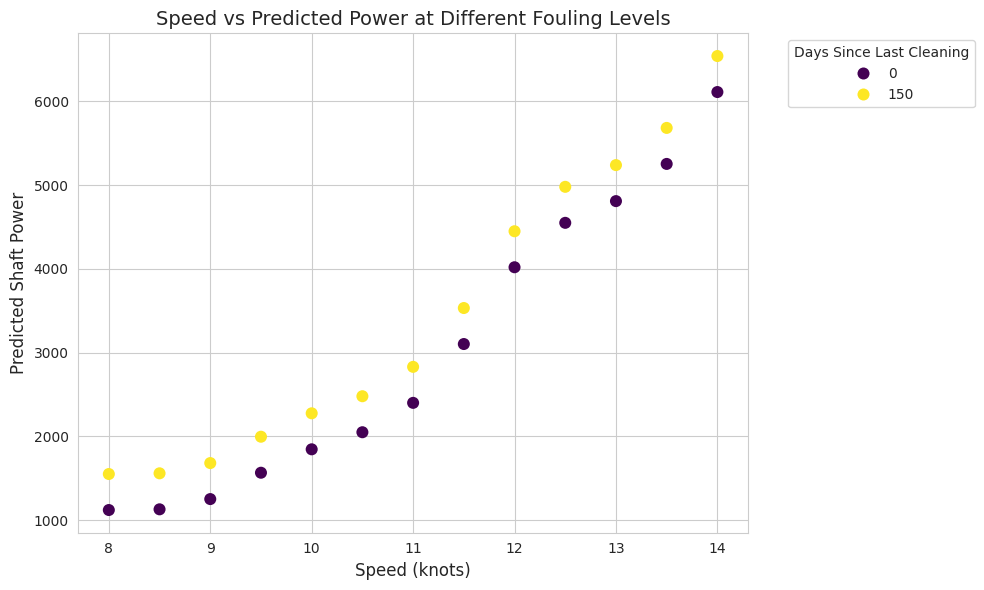

In [63]:
plot_speed_power_by_dsc(simulation_df, dsc_values=[0,150])

In [64]:
fouling_idx = all_predictive_variables.index("Days Since Last Cleaning")
print(f"Fouling is at index: {fouling_idx}")

Fouling is at index: 1


## 3.3. GAM model Evaluation

### 3.3.1. Model summary & diagnostics

Checks already confirmed:

Concurvity: Neutralized by monotonic constraints

Speed-Power Curve: Visually confirmed to follow a $V^3$ curve

Fouling Curve: Confirmed to follow a biological S-curve shape

Overfitting: Confirmed resolved (Train RMSE ≈ Test RMSE)

EDoF vs. Lambda: Confirmed model is using appropriate flexibility

Physical constraints: Confirmed monotonic on Speed, DSC, Draft, Wave Height

#### 3.3.1.1. Summary

The EDoF should not be too close to n_splines (then n_splines should be increased)

In [65]:
# 1. Extract the raw pyGAM model from our fitted pipeline
gam_pipeline = fitted_pipelines["GAM"]
actual_pygam_model = gam_pipeline.named_steps["model"].gam_model_
# 2. Generate a perfectly spaced grid of 100 points for the fouling feature
# This creates a synthetic array where ONLY the fouling feature changes.
XX = actual_pygam_model.generate_X_grid(term=days_cleaning_idx)

# 3. Extract the partial dependence (the isolated kW penalty) and the 95% confidence intervals
pdep, confi = actual_pygam_model.partial_dependence(term=days_cleaning_idx, X=XX, width=0.95)

# 4. We only want to plot the X-axis for the fouling variable itself
x_axis_values = XX[:, days_cleaning_idx]

In [66]:
all_predictive_variables

['Avg Draft (Calculated)',
 'Days Since Last Cleaning',
 'Vessel Hull Through Water Longitudinal Speed (knots)',
 'Vessel External Conditions Wind Relative Angle (degrees)',
 'Vessel External Conditions Wind Relative Speed (knots)',
 'Vessel External Conditions Sea Water Temperature (Provider S)',
 'Vessel External Conditions Wave Significant Height (Provider MB)']

In [67]:
actual_pygam_model.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     25.1029
Link Function:                     IdentityLink Log Likelihood:                               -294544.0093
Number of Samples:                        38047 AIC:                                           589140.2243
                                                AICc:                                          589140.2616
                                                GCV:                                           310872.1512
                                                Scale:                                            557.2279
                                                Pseudo R-Squared:                                   0.8609
Feature Function                  Lam

/tmp/ipykernel_31492/4038382217.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  actual_pygam_model.summary()


#### 3.3.1.2. Concurvity check

In [68]:
# Assuming your dataframe is 'df' and these are your features
target_feature = 'Days Since Last Cleaning'
other_features = all_predictive_variables.copy() # Add your other continuous variables here
other_features.remove(target_feature)  # Remove the target feature from the list of other features

# 1. Isolate the target feature (y) and the others (X)
y_concurvity = X_train[target_feature]
X_concurvity = X_train[other_features]

# 2. Fit a GAM predicting Days Since Cleaning based on the other features
# We use s(0) + s(1) to apply splines to both Speed and Draft
concurvity_model = LinearGAM(s(0) + s(1)).fit(X_concurvity, y_concurvity)

# 3. Extract the R-squared (Explained Deviance)
# 0.0 means no concurvity. 1.0 means complete overlap (bad).
concurvity_index = concurvity_model.statistics_['pseudo_r2']['explained_deviance']

print(f"Concurvity Index for {target_feature}: {concurvity_index:.4f}")
if concurvity_index > 0.7:
    print("WARNING: Severe concurvity detected. The model cannot separate the effect of fouling from the other variables.")


Concurvity Index for Days Since Last Cleaning: 0.8273


#### 3.3.1.3. residuals v predicted values

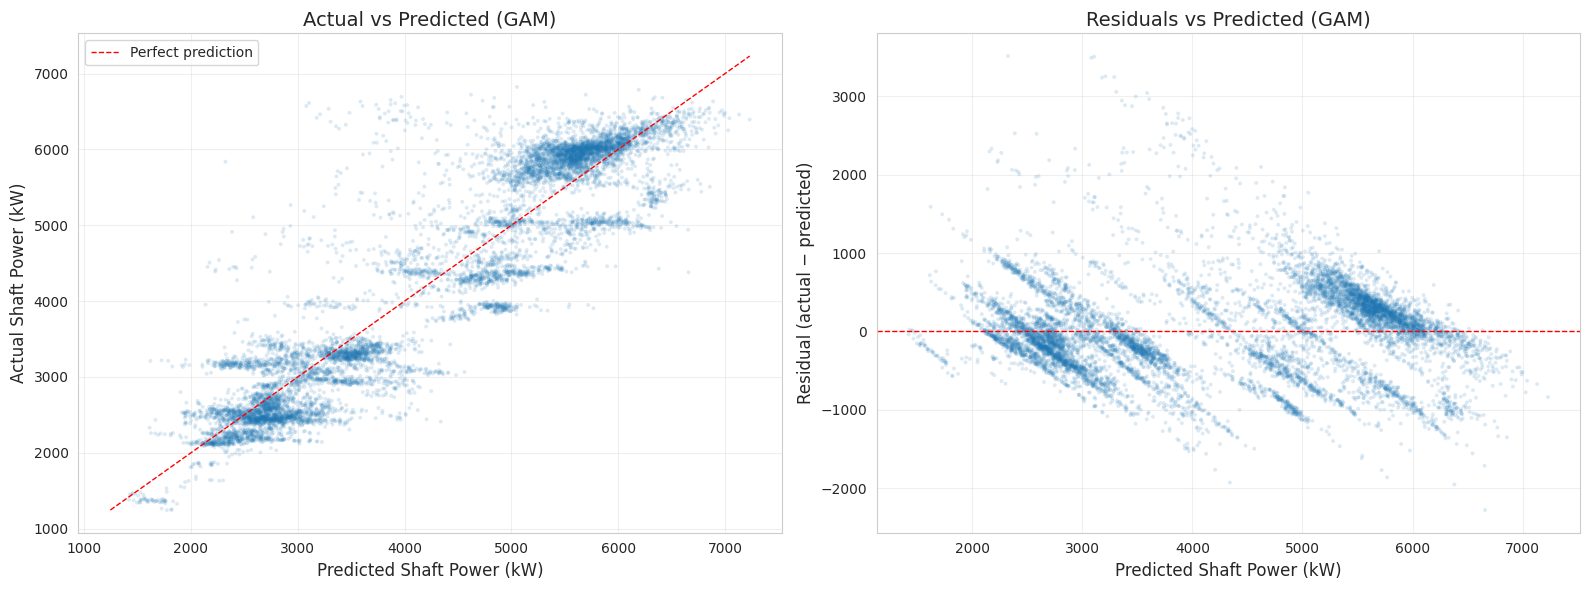

In [69]:
# Compute GAM-specific predictions on train and test sets
gam_pred_test = gam_pipeline.predict(X_test)
gam_pred_train = gam_pipeline.predict(X_train)
gam_residuals_test = np.asarray(y_test) - np.asarray(gam_pred_test)

# --- Residuals vs Predicted Values ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
axes[0].scatter(gam_pred_test, y_test, alpha=0.15, s=8, edgecolors='none')
lims = [
    min(gam_pred_test.min(), y_test.min()),
    max(gam_pred_test.max(), y_test.max()),
]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel("Predicted Shaft Power (kW)", fontsize=12)
axes[0].set_ylabel("Actual Shaft Power (kW)", fontsize=12)
axes[0].set_title("Actual vs Predicted (GAM)", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals vs Predicted
axes[1].scatter(gam_pred_test, gam_residuals_test, alpha=0.15, s=8, edgecolors='none')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel("Predicted Shaft Power (kW)", fontsize=12)
axes[1].set_ylabel("Residual (actual − predicted)", fontsize=12)
axes[1].set_title("Residuals vs Predicted (GAM)", fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 3.3.1.4. QQ plot / normality of residuals

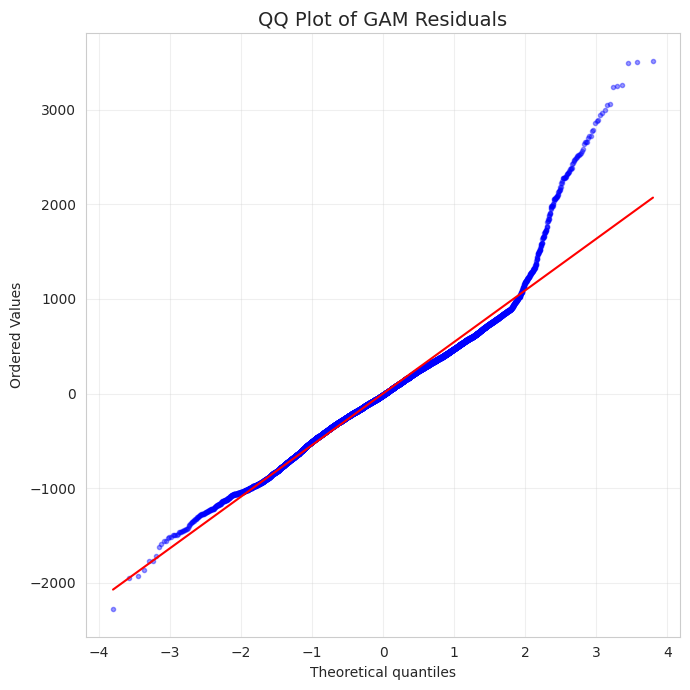

Shapiro-Wilk test  →  statistic = 0.960199,  p-value = 5.6973e-35
Residuals are NOT normally distributed (reject H₀ at α = 0.05).


In [70]:

# --- QQ Plot of GAM residuals ---
fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(gam_residuals_test, dist="norm", plot=ax)
ax.set_title("QQ Plot of GAM Residuals", fontsize=14)
ax.get_lines()[0].set(markersize=3, alpha=0.4)  # data points
ax.get_lines()[1].set(color='red', linewidth=1.5)  # reference line
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Shapiro-Wilk test on a subsample (max 5000 for performance)
sample = gam_residuals_test if len(gam_residuals_test) <= 5000 else np.random.default_rng(random_seed).choice(gam_residuals_test, 5000, replace=False)
stat, p_value = stats.shapiro(sample)
print(f"Shapiro-Wilk test  →  statistic = {stat:.6f},  p-value = {p_value:.4e}")
if p_value < 0.05:
    print("Residuals are NOT normally distributed (reject H₀ at α = 0.05).")
else:
    print("Residuals appear normally distributed (fail to reject H₀ at α = 0.05).")

#### 3.3.1.5. residuals over time

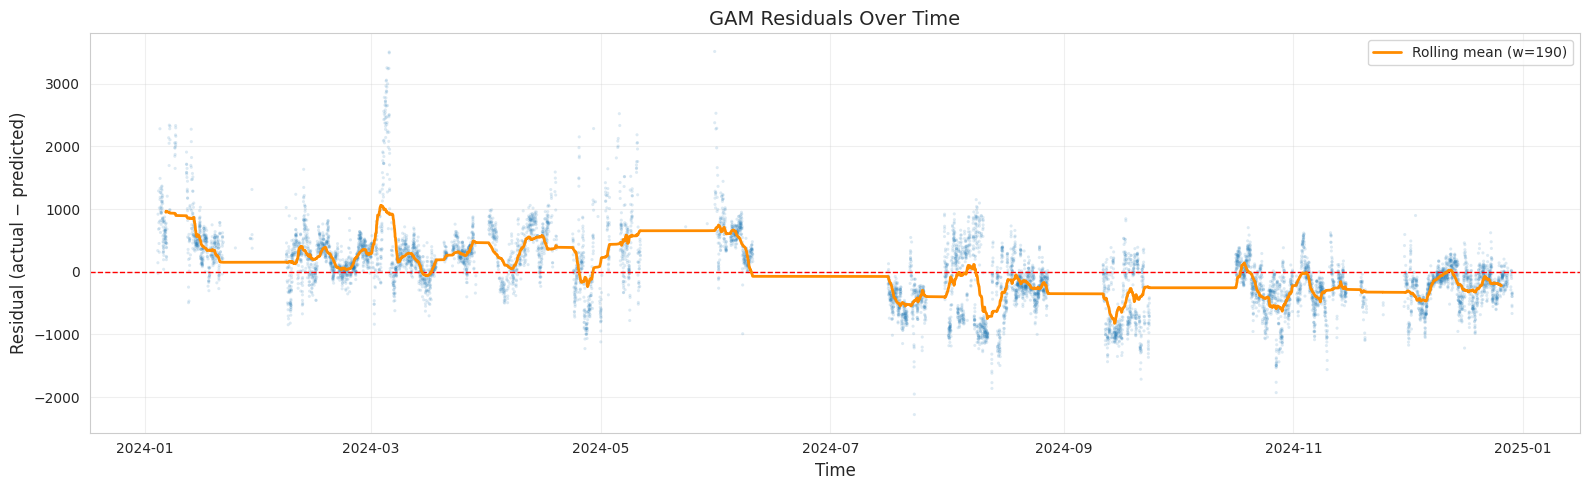

In [71]:
# --- Residuals over time ---
test_times = model_df.loc[X_test.index, "window_start"]

fig, ax = plt.subplots(figsize=(16, 5))
ax.scatter(test_times, gam_residuals_test, alpha=0.15, s=5, edgecolors='none')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)

# Rolling mean of residuals to highlight drift
rolling_df = pd.DataFrame({"time": test_times.values, "residual": gam_residuals_test}).sort_values("time")
window = max(len(rolling_df) // 50, 10)
rolling_mean = rolling_df["residual"].rolling(window=window, center=True).mean()
ax.plot(rolling_df["time"], rolling_mean, color='darkorange', linewidth=2, label=f'Rolling mean (w={window})')

ax.set_title("GAM Residuals Over Time", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Residual (actual − predicted)", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 3.3.1.6. Residuals vs days since cleaning

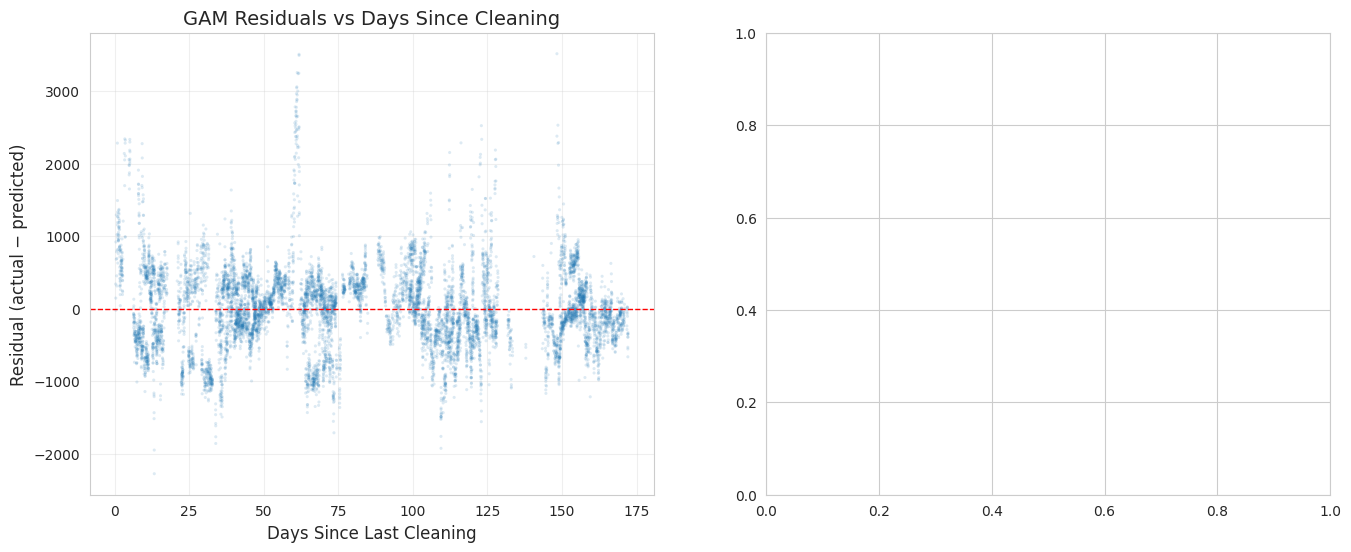

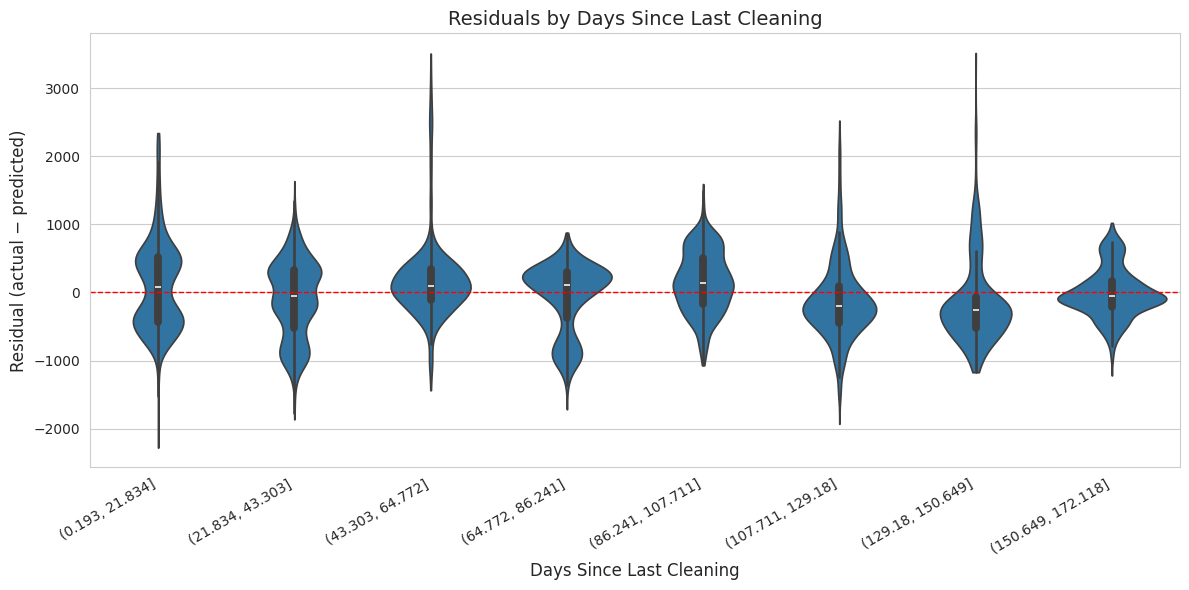

In [72]:
def plot_residual_boxplots(
    X_test,
    y_test,
    y_pred,
    variable_name,
    n_buckets=5,
    value_limits=None,
):
    """
    Creates a violin plot of residuals bucketed by a comparison variable.

    Parameters
    ----------
    X_test : pd.DataFrame
        Test feature matrix.
    y_test : pd.Series or np.ndarray
        True target values.
    y_pred : np.ndarray
        Predicted target values.
    variable_name : str
        Column name in X_test to bucket by.
    n_buckets : int, optional
        Number of equal-frequency (quantile) buckets (default 5).
    value_limits : tuple of (min, max), optional
        If provided, clips the comparison variable to [min, max] before
        bucketing, and drops rows outside this range.
    """
    residuals = np.asarray(y_test) - np.asarray(y_pred)
    plot_df = pd.DataFrame({
        "variable": X_test[variable_name].values,
        "residual": residuals,
    })

    # optional filtering by value limits
    if value_limits is not None:
        lo, hi = value_limits
        plot_df = plot_df[(plot_df["variable"] >= lo) & (plot_df["variable"] <= hi)]

    # create buckets using quantile-based binning
    plot_df["bucket"] = pd.cut(
        plot_df["variable"],
        bins=n_buckets,
        duplicates="drop",
    )

    # sort by bucket for a clean axis order
    plot_df = plot_df.sort_values("bucket")

    # plot
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.violinplot(
        data=plot_df,
        x="bucket",
        y="residual",
        ax=ax,
        inner="box",
        cut=0,
    )
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Residuals by {variable_name}", fontsize=14)
    ax.set_xlabel(variable_name, fontsize=12)
    ax.set_ylabel("Residual (actual − predicted)", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# --- Residuals vs Days Since Last Cleaning ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: scatter
axes[0].scatter(X_test["Days Since Last Cleaning"], gam_residuals_test, alpha=0.15, s=5, edgecolors='none')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel("Days Since Last Cleaning", fontsize=12)
axes[0].set_ylabel("Residual (actual − predicted)", fontsize=12)
axes[0].set_title("GAM Residuals vs Days Since Cleaning", fontsize=14)
axes[0].grid(True, alpha=0.3)

# Right: violin plot bucketed by DSC
plot_residual_boxplots(
    X_test=X_test,
    y_test=y_test,
    y_pred=gam_pred_test,
    variable_name="Days Since Last Cleaning",
    n_buckets=8,
)

#### 3.3.1.7. Sea trial curves validation


2026-02-26 09:29:44.227 | INFO     | __main__:<module>:14 - Rows within 7 days of a cleaning event: 856


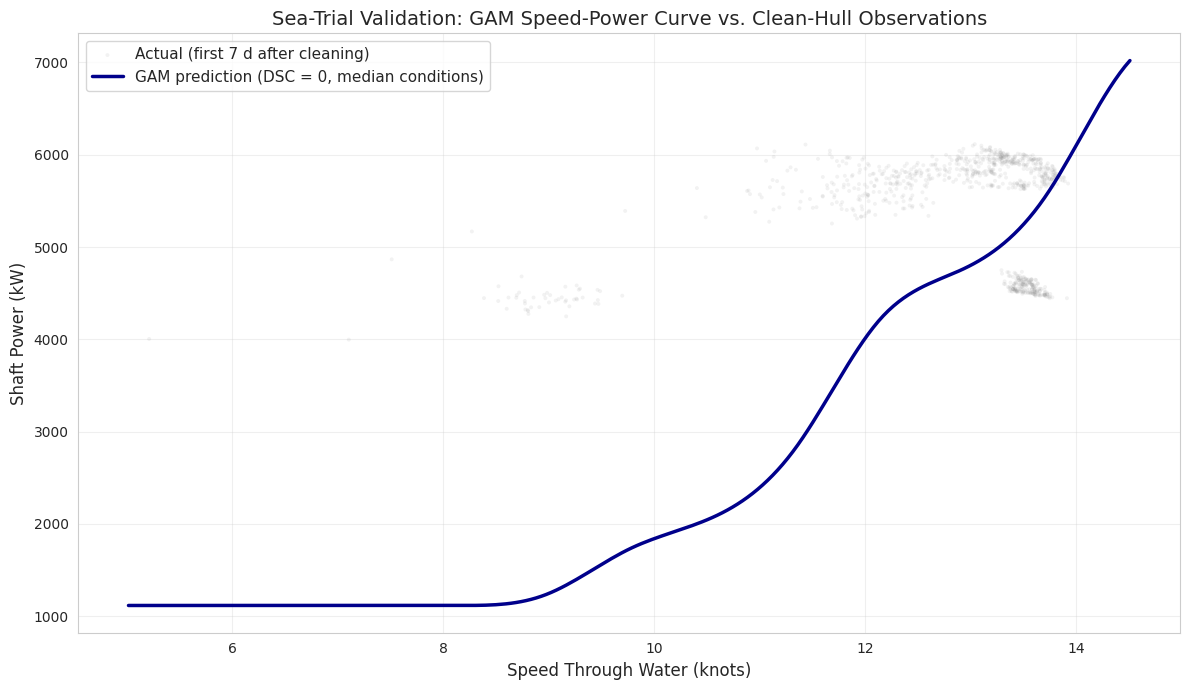

In [73]:
# --- 3.3.1.7  Sea Trial Curves Validation ---
# Compare the GAM's speed-power curve (at a clean-hull baseline) against
# actual observations from the first 7 days after each cleaning event.

CLEANING_DATES = [
    pd.Timestamp("2024-01-04", tz="UTC"),
    pd.Timestamp("2024-07-10", tz="UTC"),
]
CLEAN_HULL_DAYS = 7  # only keep the first N days after each cleaning

# 1. Identify rows within `CLEAN_HULL_DAYS` of any cleaning event
clean_hull_mask = model_df["Days Since Last Cleaning"] <= CLEAN_HULL_DAYS
clean_df = model_df[clean_hull_mask].copy()
logger.info(f"Rows within {CLEAN_HULL_DAYS} days of a cleaning event: {len(clean_df):,}")

# 2. Build a synthetic "sea trial" prediction from the GAM
#    Hold every variable at its typical (median) value except speed, and set DSC = 0.
speed_range = np.linspace(
    X_train[speed_variable].min(),
    X_train[speed_variable].max(),
    200,
)

sea_trial_rows = []
for spd in speed_range:
    row = {feat: X_train[feat].median() for feat in all_predictive_variables}
    row[speed_variable] = spd
    row[dsc_variable] = 0  # perfectly clean hull
    sea_trial_rows.append(row)

sea_trial_df = pd.DataFrame(sea_trial_rows)
sea_trial_df["Predicted Shaft Power"] = gam_pipeline.predict(sea_trial_df[all_predictive_variables])

# 3. Also predict on the real clean-hull observations for comparison
clean_pred = gam_pipeline.predict(clean_df[all_predictive_variables])

# 4. Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter: actual observations from the clean-hull period
ax.scatter(
    clean_df[speed_variable],
    clean_df[TARGET_COLUMN],
    alpha=0.10, s=8, edgecolors="none", color="grey",
    label=f"Actual (first {CLEAN_HULL_DAYS} d after cleaning)",
)

# Line: GAM prediction at DSC = 0 (synthetic sea-trial curve)
ax.plot(
    sea_trial_df[speed_variable],
    sea_trial_df["Predicted Shaft Power"],
    color="darkblue", linewidth=2.5,
    label="GAM prediction (DSC = 0, median conditions)",
)

ax.set_title("Sea-Trial Validation: GAM Speed-Power Curve vs. Clean-Hull Observations", fontsize=14)
ax.set_xlabel("Speed Through Water (knots)", fontsize=12)
ax.set_ylabel("Shaft Power (kW)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### 3.3.1.8. Cleaning event reset check


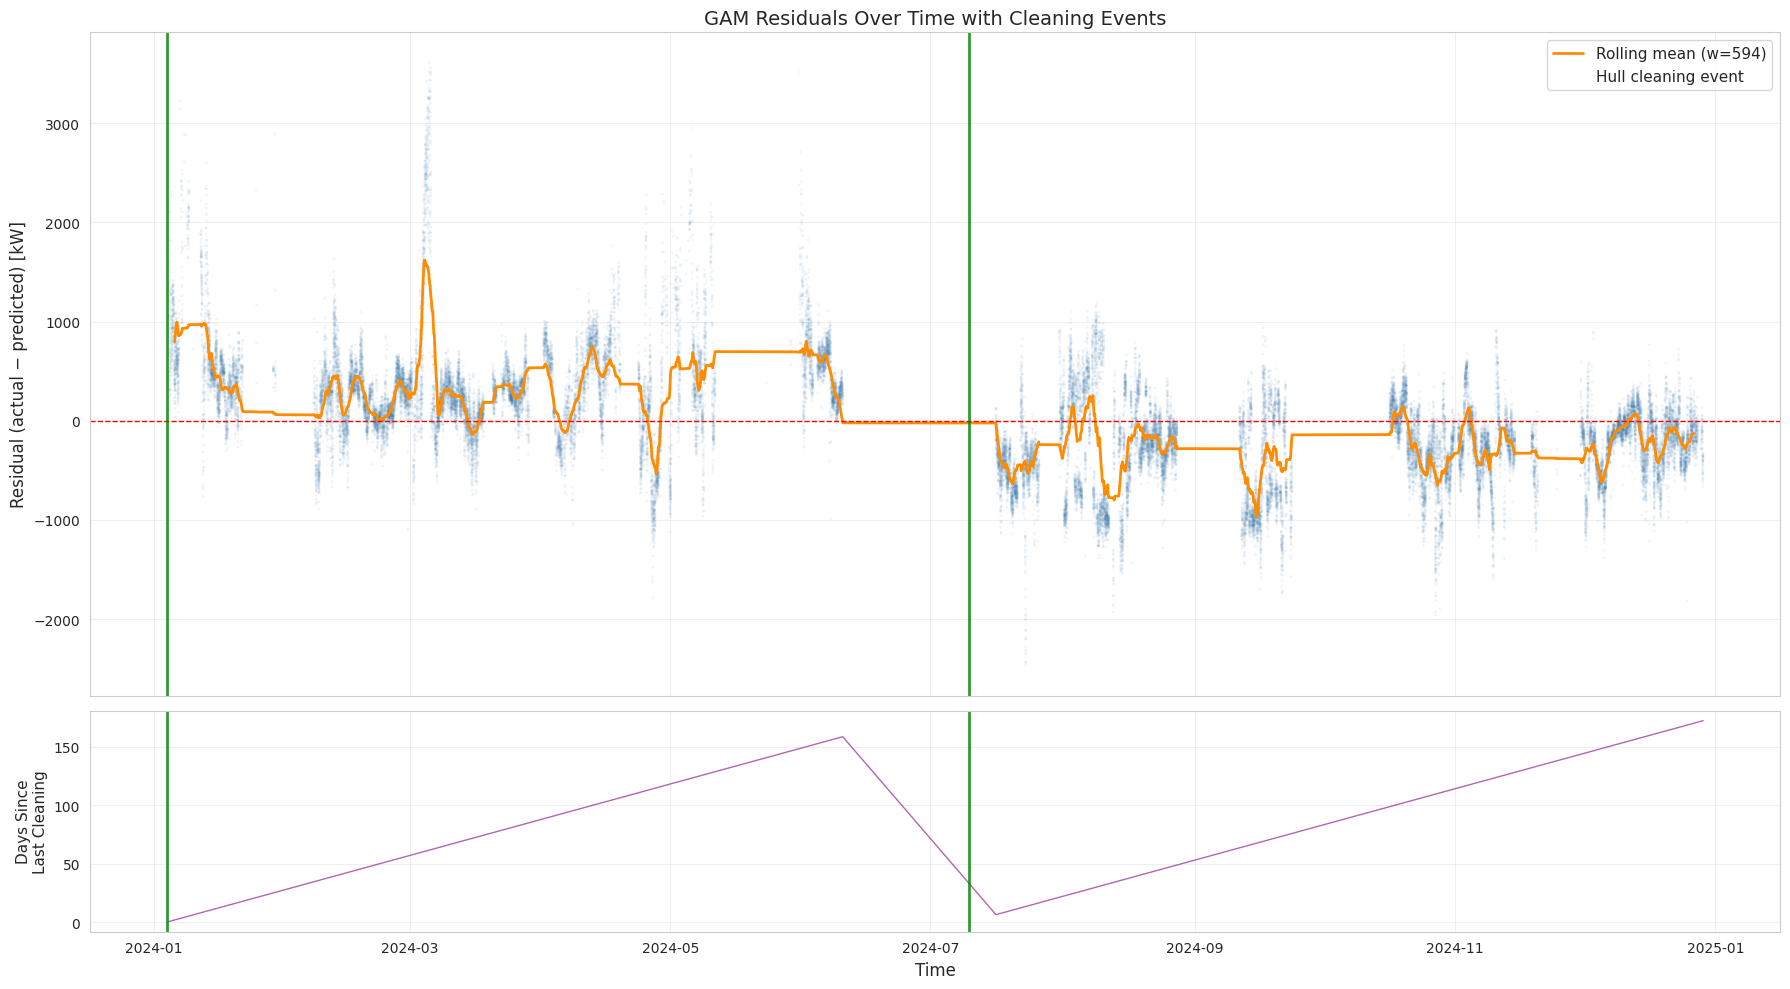

2026-02-26 09:29:47.248 | INFO     | __main__:<module>:69 - Mean residual  0-7 days after cleaning : +643.4 kW  (n=856)
2026-02-26 09:29:47.249 | INFO     | __main__:<module>:70 - Mean residual 90+ days after cleaning  : -37.5 kW  (n=21,572)
2026-02-26 09:29:47.250 | INFO     | __main__:<module>:71 - Difference (late − early)              : -680.9 kW


In [74]:
# --- 3.3.1.8  Cleaning Event Reset Check ---
# Plot GAM residuals on the full dataset over time, with vertical lines at
# each hull-cleaning date.  If the fouling term is working correctly the
# residuals should jump toward zero (or go negative) right after a cleaning
# and then drift positive as fouling accumulates.

CLEANING_DATES = [
    pd.Timestamp("2024-01-04", tz="UTC"),
    pd.Timestamp("2024-07-10", tz="UTC"),
]

# 1. Predict on the FULL dataset (train + test) so we can see the entire timeline
full_pred = gam_pipeline.predict(model_df[all_predictive_variables])
full_residuals = model_df[TARGET_COLUMN].values - full_pred
full_times = model_df["window_start"].values

# 2. Build a tidy frame sorted by time for the rolling mean
res_df = (
    pd.DataFrame({"time": full_times, "residual": full_residuals})
    .sort_values("time")
    .reset_index(drop=True)
)

roll_w = max(len(res_df) // 80, 20)
res_df["rolling_mean"] = res_df["residual"].rolling(window=roll_w, center=True).mean()

# 3. Plot
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

# --- Top panel: residuals + rolling mean ---
ax = axes[0]
ax.scatter(res_df["time"], res_df["residual"],
           alpha=0.08, s=4, edgecolors="none", color="steelblue")
ax.plot(res_df["time"], res_df["rolling_mean"],
        color="darkorange", linewidth=2, label=f"Rolling mean (w={roll_w})")
ax.axhline(y=0, color="red", linestyle="--", linewidth=1)

for cd in CLEANING_DATES:
    ax.axvline(x=cd, color="green", linestyle="-", linewidth=2, alpha=0.8)
# Add a single legend entry for cleaning lines
ax.axvline(x=CLEANING_DATES[0], color="green", linestyle="-", linewidth=0,
           label="Hull cleaning event")

ax.set_ylabel("Residual (actual − predicted) [kW]", fontsize=12)
ax.set_title("GAM Residuals Over Time with Cleaning Events", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# --- Bottom panel: Days Since Last Cleaning ---
ax2 = axes[1]
ax2.plot(model_df["window_start"].values,
         model_df["Days Since Last Cleaning"].values,
         color="purple", linewidth=1, alpha=0.6)
for cd in CLEANING_DATES:
    ax2.axvline(x=cd, color="green", linestyle="-", linewidth=2, alpha=0.8)

ax2.set_ylabel("Days Since\nLast Cleaning", fontsize=11)
ax2.set_xlabel("Time", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Quantitative check: compare mean residual in [0,7] days vs [90+] days
early = res_df.loc[model_df["Days Since Last Cleaning"].values <= 7, "residual"]
late  = res_df.loc[model_df["Days Since Last Cleaning"].values >= 90, "residual"]

logger.info(f"Mean residual  0-7 days after cleaning : {early.mean():+.1f} kW  (n={len(early):,})")
logger.info(f"Mean residual 90+ days after cleaning  : {late.mean():+.1f} kW  (n={len(late):,})")
logger.info(f"Difference (late − early)              : {late.mean() - early.mean():+.1f} kW")


### 3.3.2. Fouling / speed curve

#### 3.3.2.1. Fouling penalty by day since clean

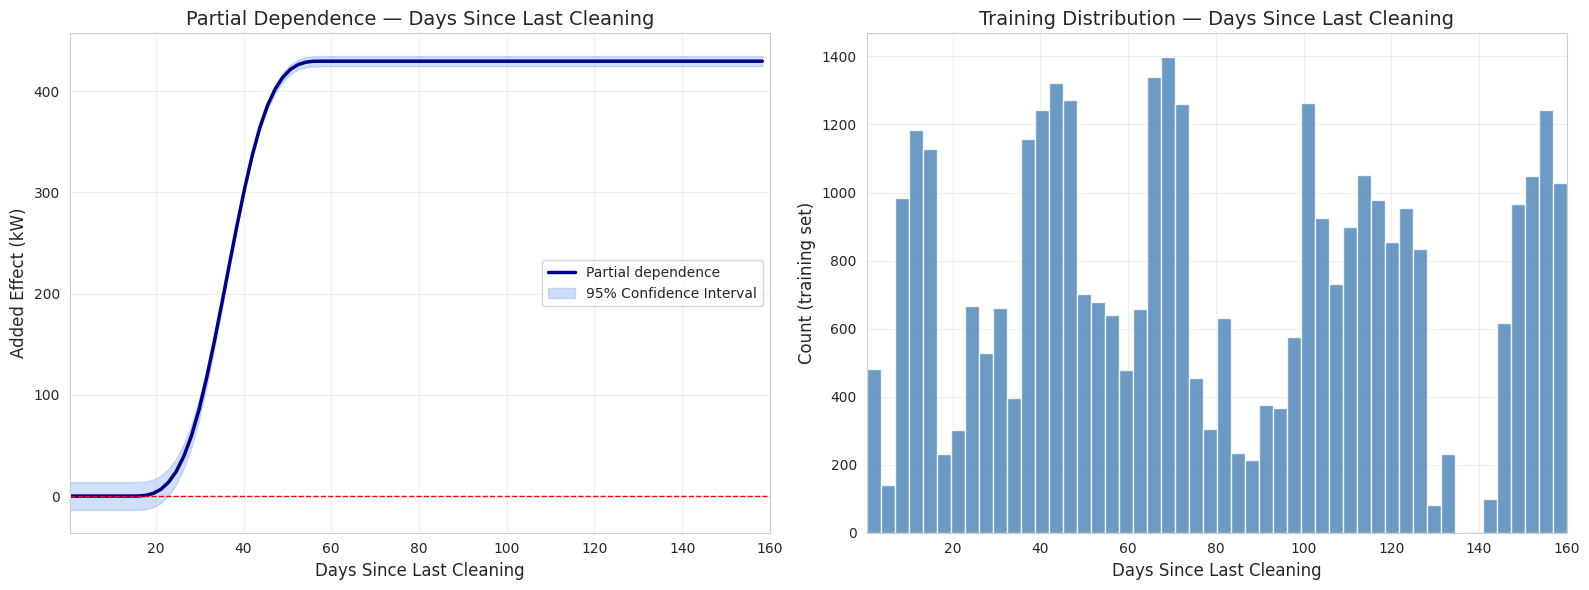

2026-02-26 09:38:20.030 | INFO     | __main__:plot_partial_dependence:110 - Max partial dependence for 'Days Since Last Cleaning': 429.6 kW  (which is 10.1% of the average shaft power)


(<Figure size 1600x600 with 2 Axes>,
 array([<Axes: title={'center': 'Partial Dependence — Days Since Last Cleaning'}, xlabel='Days Since Last Cleaning', ylabel='Added Effect (kW)'>,
        <Axes: title={'center': 'Training Distribution — Days Since Last Cleaning'}, xlabel='Days Since Last Cleaning', ylabel='Count (training set)'>],
       dtype=object))

In [87]:
def plot_partial_dependence(
    pipeline,
    predictive_variables,
    variable_name,
    X_train=None,
    max_value=None,
    shift_to_zero=True,
    figsize=(16, 6),
    ci_width=0.95,
):
    """
    Plot the partial dependence of a single variable from a fitted GAM pipeline,
    alongside a histogram of that variable's distribution in the training set.

    Parameters
    ----------
    pipeline : sklearn.pipeline.Pipeline
        A fitted pipeline with a 'preprocessor' (containing a StandardScaler
        under 'numeric') and a 'model' (SklearnGAM wrapper).
    predictive_variables : list of str
        The ordered list of feature names used during training.
    variable_name : str
        The name of the variable to visualise.
    X_train : pd.DataFrame, optional
        Training feature matrix. If provided, a histogram of the variable's
        distribution is plotted in a second panel.
    max_value : float, optional
        If given, clip the x-axis to this upper bound.
    shift_to_zero : bool, default True
        Shift the curve so it starts at y = 0 (easier to read as "added effect").
    figsize : tuple, default (16, 6)
        Figure size for the two-panel layout.
    ci_width : float, default 0.95
        Width of the confidence interval (0-1).

    Returns
    -------
    fig, axes : matplotlib Figure and array of Axes
    """
    # 1. Extract objects from the pipeline
    actual_pygam_model = pipeline.named_steps["model"].gam_model_
    scaler = pipeline.named_steps["preprocessor"].named_transformers_["numeric"].named_steps["scaler"]
    var_idx = predictive_variables.index(variable_name)

    # 2. Generate grid & partial dependence (in scaled space)
    XX = actual_pygam_model.generate_X_grid(term=var_idx)
    pdep, confi = actual_pygam_model.partial_dependence(term=var_idx, X=XX, width=ci_width)

    # 3. Unscale the grid so the x-axis is in real units
    XX_unscaled = scaler.inverse_transform(XX)
    real_values = XX_unscaled[:, var_idx]

    # 4. Optionally filter to max_value
    if max_value is not None:
        mask = real_values <= max_value
        real_values = real_values[mask]
        pdep = pdep[mask]
        confi = confi[mask]

    # 5. Optionally shift so the curve starts at 0
    if shift_to_zero:
        baseline = pdep[0]
        pdep = pdep - baseline
        confi = confi - baseline

    # 6. Create figure with two side-by-side panels
    n_cols = 2 if X_train is not None else 1
    fig, axes = plt.subplots(1, n_cols, figsize=figsize)
    if n_cols == 1:
        axes = [axes]

    # --- Left panel: partial dependence ---
    ax = axes[0]
    ax.plot(real_values, pdep, color="darkblue", linewidth=2.5, label="Partial dependence")
    ax.fill_between(
        real_values, confi[:, 0], confi[:, 1],
        color="cornflowerblue", alpha=0.3,
        label=f"{int(ci_width * 100)}% Confidence Interval",
    )
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel(variable_name, fontsize=12)
    ylabel = "Added Effect (kW)" if shift_to_zero else "Partial Dependence (kW)"
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Partial Dependence — {variable_name}", fontsize=14)
    if max_value is not None:
        ax.set_xlim(real_values.min(), max_value)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- Right panel: histogram of training values ---
    if X_train is not None:
        ax2 = axes[1]
        train_vals = X_train[variable_name]
        if max_value is not None:
            train_vals = train_vals[train_vals <= max_value]
        ax2.hist(train_vals, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
        ax2.set_xlabel(variable_name, fontsize=12)
        ax2.set_ylabel("Count (training set)", fontsize=12)
        ax2.set_title(f"Training Distribution — {variable_name}", fontsize=14)
        if max_value is not None:
            ax2.set_xlim(real_values.min(), max_value)
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print the max effect size
    max_effect = pdep.max()
    mean_shaft_power = y_train.mean()
    logger.info(f"Max partial dependence for '{variable_name}': {max_effect:.1f} kW  (which is {max_effect / mean_shaft_power:.1%} of the average shaft power)")
    
    return fig, axes


# --- Example: reproduce the original fouling curve ---
plot_partial_dependence(
    pipeline=gam_pipeline,
    predictive_variables=all_predictive_variables,
    variable_name="Days Since Last Cleaning",
    X_train=X_train,
    max_value=160,
    shift_to_zero=True,
)

2026-02-26 09:29:47.743 | INFO     | __main__:<module>:2 - Plotting partial dependence for: Avg Draft (Calculated)


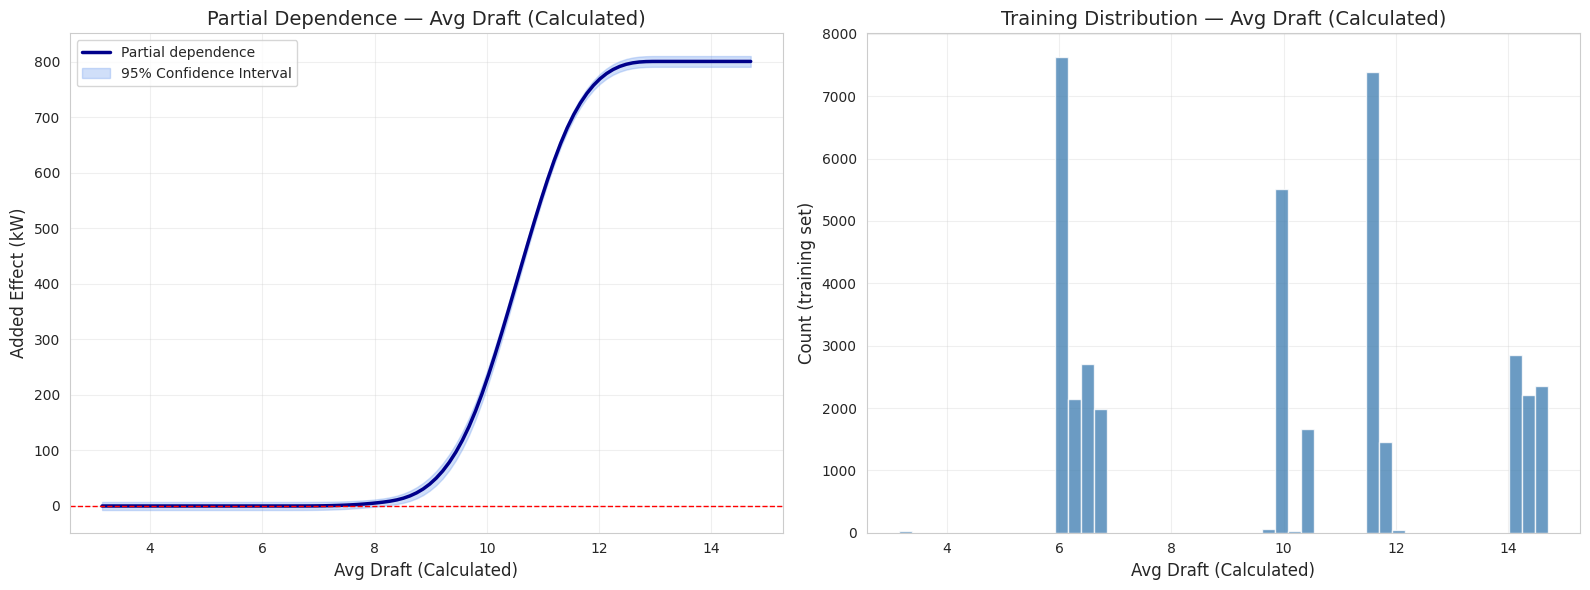

2026-02-26 09:29:48.197 | INFO     | __main__:<module>:2 - Plotting partial dependence for: Days Since Last Cleaning


Max effect for Avg Draft (Calculated): 800.46 kW


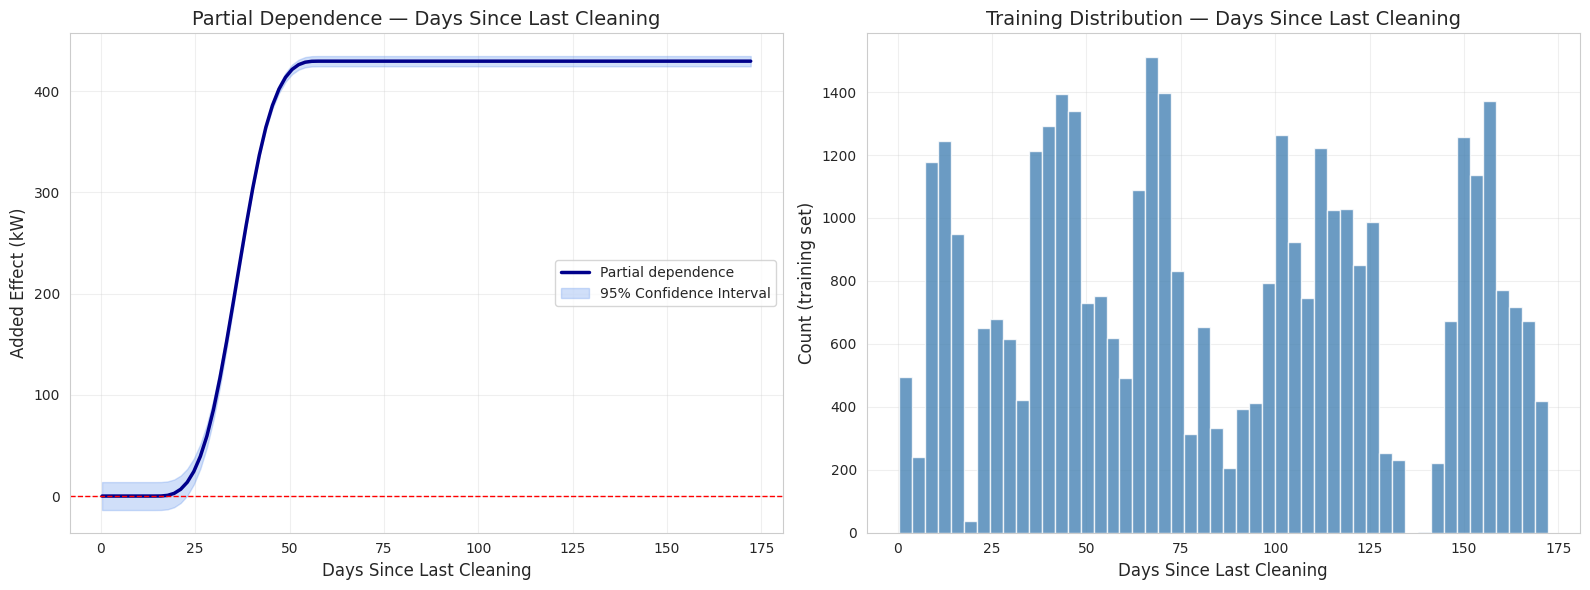

2026-02-26 09:29:48.758 | INFO     | __main__:<module>:2 - Plotting partial dependence for: Vessel Hull Through Water Longitudinal Speed (knots)


Max effect for Days Since Last Cleaning: 429.65 kW


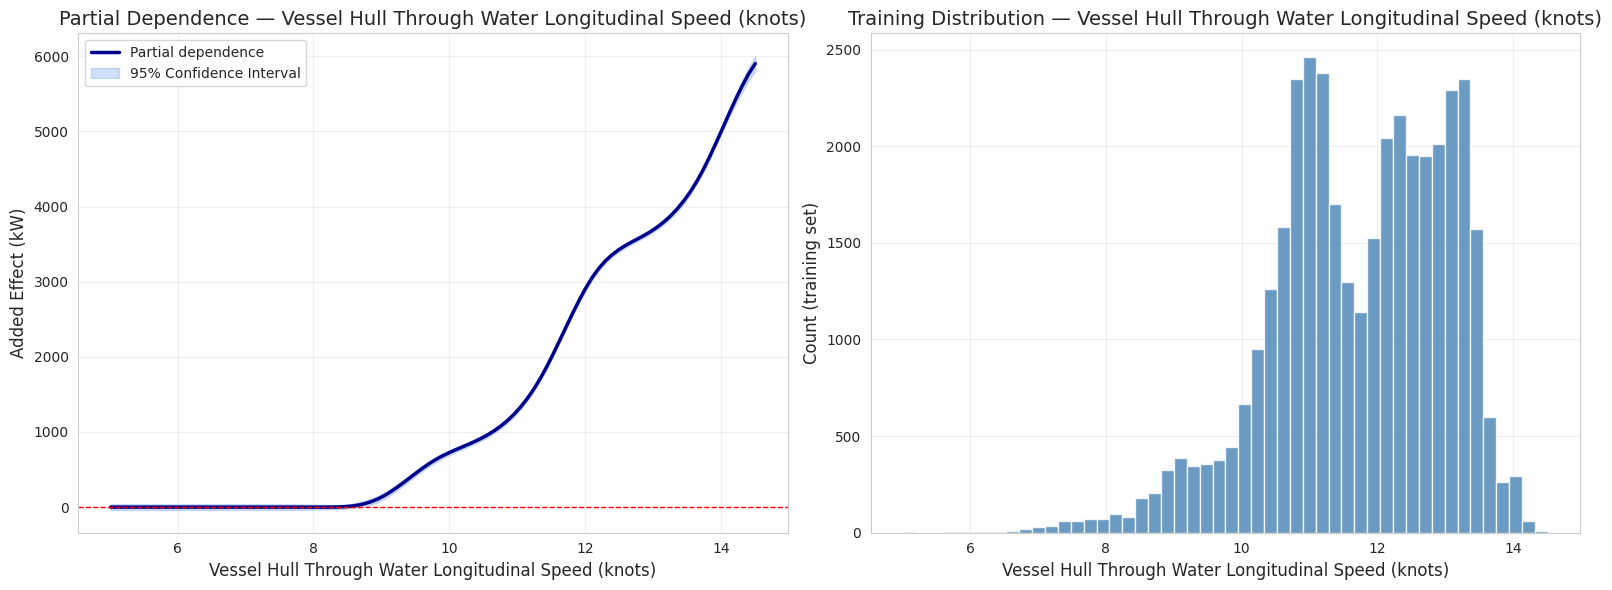

2026-02-26 09:29:49.284 | INFO     | __main__:<module>:2 - Plotting partial dependence for: Vessel External Conditions Wind Relative Angle (degrees)


Max effect for Vessel Hull Through Water Longitudinal Speed (knots): 5903.32 kW


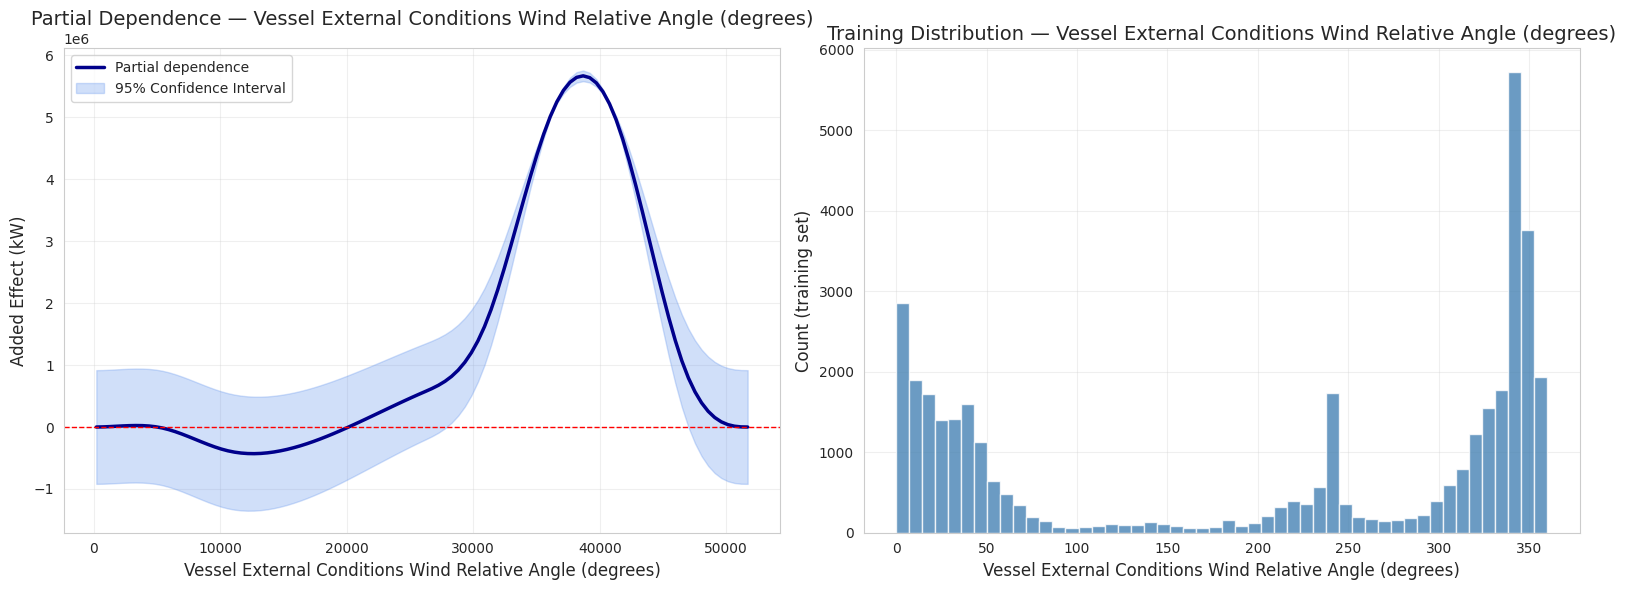

2026-02-26 09:29:49.832 | INFO     | __main__:<module>:2 - Plotting partial dependence for: Vessel External Conditions Wind Relative Speed (knots)


Max effect for Vessel External Conditions Wind Relative Angle (degrees): 5666421.32 kW


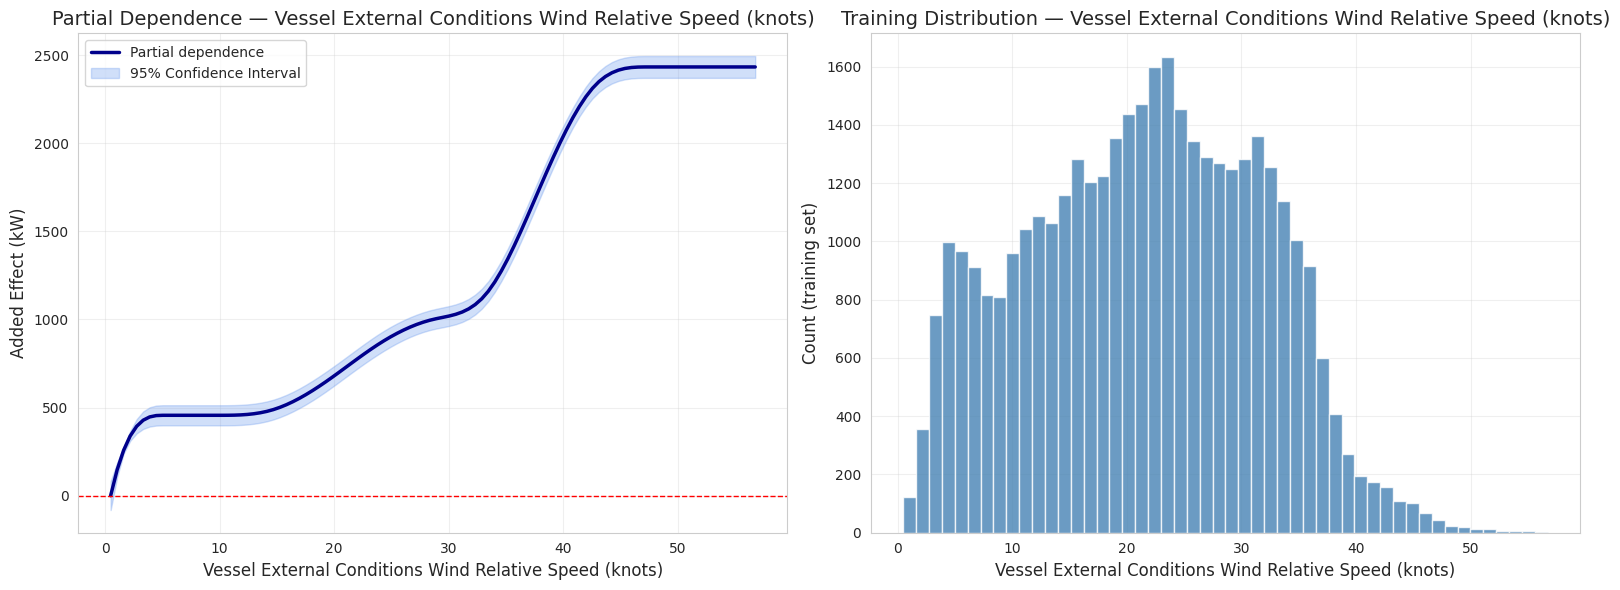

2026-02-26 09:29:50.288 | INFO     | __main__:<module>:2 - Plotting partial dependence for: Vessel External Conditions Sea Water Temperature (Provider S)


Max effect for Vessel External Conditions Wind Relative Speed (knots): 2432.41 kW


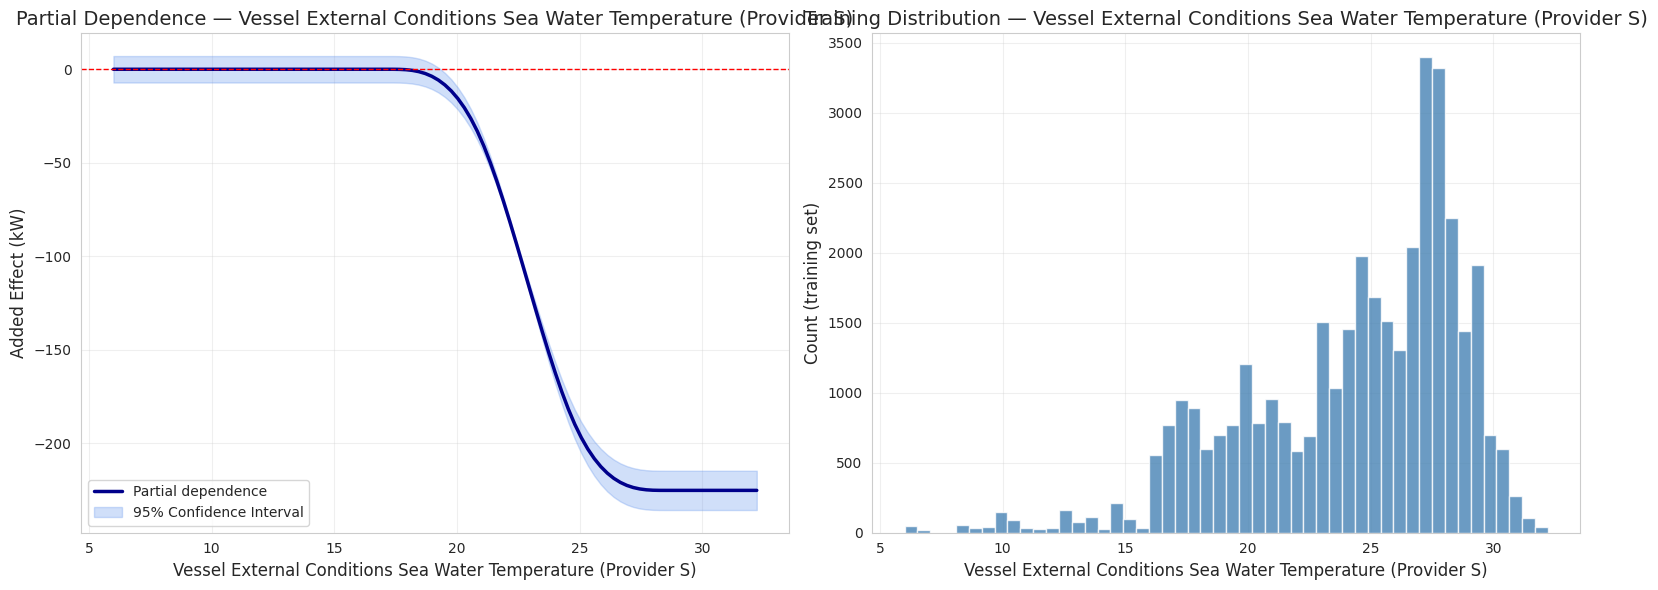

2026-02-26 09:29:50.730 | INFO     | __main__:<module>:2 - Plotting partial dependence for: Vessel External Conditions Wave Significant Height (Provider MB)


Max effect for Vessel External Conditions Sea Water Temperature (Provider S): 0.00 kW


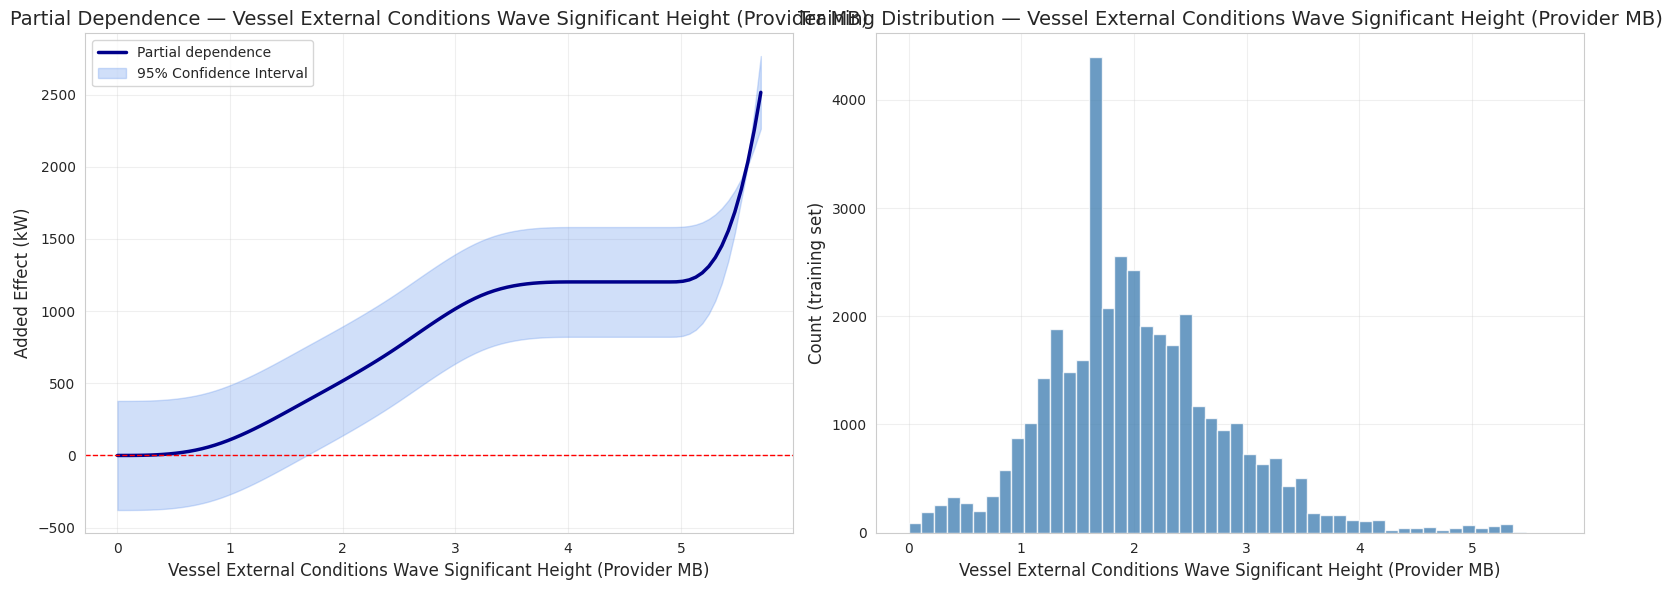

Max effect for Vessel External Conditions Wave Significant Height (Provider MB): 2516.15 kW


In [76]:
for variable in all_predictive_variables:
    logger.info(f"Plotting partial dependence for: {variable}")
    plot_partial_dependence(
        pipeline=gam_pipeline,
        predictive_variables=all_predictive_variables,
        variable_name=variable,
        X_train=X_train,
        shift_to_zero=True,
    )   


### 3.3.2.1 Fouling penalty by speed

In [77]:
simulation_df

,Avg Draft (Calculated),Days Since Last Cleaning,Vessel Hull Through Water Longitudinal Speed (knots),Vessel External Conditions Wind Relative Angle (degrees),Vessel External Conditions Wind Relative Speed (knots),Vessel External Conditions Sea Water Temperature (Provider S),Vessel External Conditions Wave Significant Height (Provider MB),Predicted Shaft Power
0,9.945,0,8,205.104928,21.48077,24.297915,2.011421,1121.790142
1,9.945,1,8,205.104928,21.48077,24.297915,2.011421,1121.790130
2,9.945,2,8,205.104928,21.48077,24.297915,2.011421,1121.790117
3,9.945,3,8,205.104928,21.48077,24.297915,2.011421,1121.790103
4,9.945,4,8,205.104928,21.48077,24.297915,2.011421,1121.790088
...,...,...,...,...,...,...,...,...
1958,9.945,146,14,205.104928,21.48077,24.297915,2.011421,6538.858083
1959,9.945,147,14,205.104928,21.48077,24.297915,2.011421,6538.858068
1960,9.945,148,14,205.104928,21.48077,24.297915,2.011421,6538.858053
1961,9.945,149,14,205.104928,21.48077,24.297915,2.011421,6538.858039


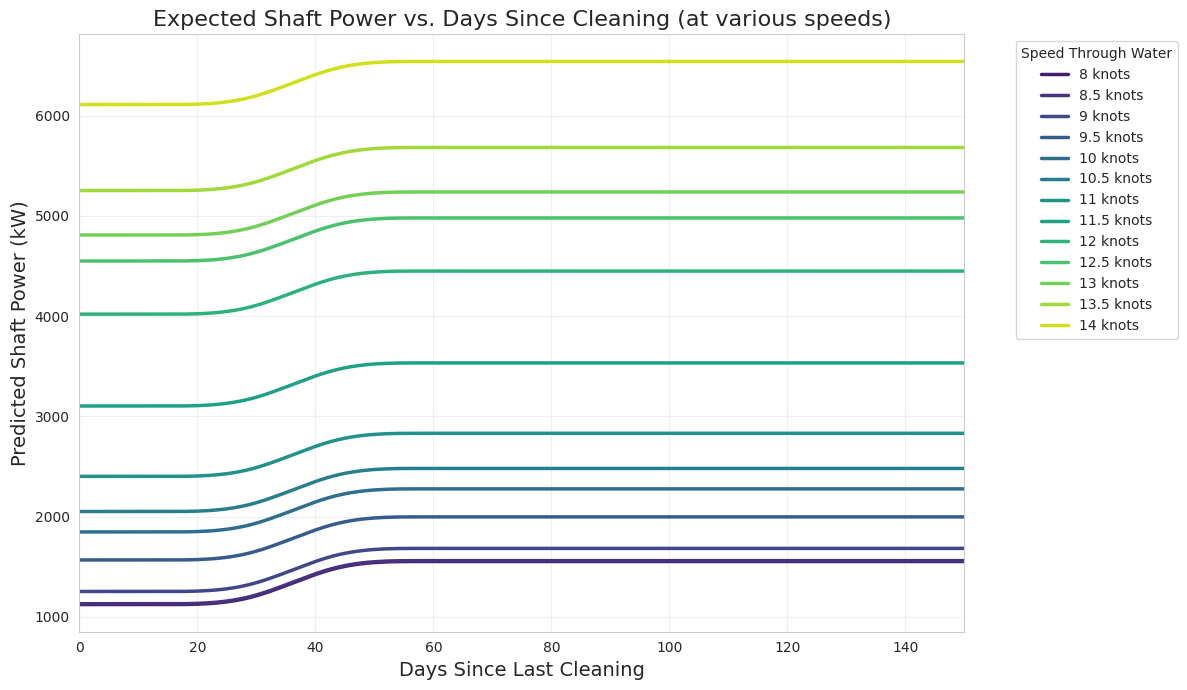

In [78]:

# overwrite the "Predicted Shaft Power" column in the simulation dataframe with the predicted values from the GAM model instead of the RF
simulation_df['Predicted Shaft Power'] = gam_pipeline.predict(simulation_df[all_predictive_variables])

# Set a nice color palette for the different speeds
unique_speeds = sorted(simulation_df['Vessel Hull Through Water Longitudinal Speed (knots)'].unique())
colors = sns.color_palette("viridis", len(unique_speeds))

plt.figure(figsize=(12, 7))

# Plot one line for each Speed
for i, speed in enumerate(unique_speeds):
    # Filter the dataframe for this specific speed
    subset = simulation_df[simulation_df['Vessel Hull Through Water Longitudinal Speed (knots)'] == speed]
    
    # Plot Days vs Predicted Power
    plt.plot(
        subset['Days Since Last Cleaning'], 
        subset['Predicted Shaft Power'], 
        linewidth=2.5, 
        color=colors[i],
        label=f"{speed} knots"
    )

# Formatting
plt.title("Expected Shaft Power vs. Days Since Cleaning (at various speeds)", fontsize=16)
plt.xlabel("Days Since Last Cleaning", fontsize=14)
plt.ylabel("Predicted Shaft Power (kW)", fontsize=14)
plt.xlim(0, 150)

# Add a legend to show which line is which speed
plt.legend(title="Speed Through Water", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout() # Ensures the legend isn't cut off
plt.show()


## 3.4. Random Forest / Metamodel


### 3.4.1. Metamodel

In [178]:
# Get the RF pipeline from your fitted_pipelines dict
rf_pipeline = fitted_pipelines["RandomForest"]

# Generate RF predictions on X_train to use as metamodel target
y_meta = rf_pipeline.predict(X_train)

#### 3.4.0 Make synthetic test datafranes

In [179]:
def make_synthetic_dataframe(
    pipeline,
    X_train,
    all_predictive_variables,
    dsc_min=0,
    dsc_max=150,
    n_points=151,
    variable_values: dict | None = None,
):
    """
    Build a synthetic DataFrame that varies only Days Since Last Cleaning
    while holding every other feature at its median (or a custom value).

    Parameters
    ----------
    pipeline : fitted sklearn Pipeline
        Used to generate predictions.
    X_train : pd.DataFrame
        Training data (used to derive median values).
    all_predictive_variables : list[str]
        Ordered list of feature names the pipeline expects.
    dsc_min, dsc_max : float
        Bounds of the DSC grid.
    n_points : int
        Number of evenly spaced DSC values to generate.
    variable_values : dict, optional
        {feature_name: value} overrides for any variable.
        If a feature is not in this dict its median from X_train is used.

    Returns
    -------
    X_synth : pd.DataFrame
        Synthetic feature matrix with a 'Predicted Shaft Power' column.
    dsc_range : np.ndarray
        The DSC values used.
    y_pred : np.ndarray
        Pipeline predictions.
    """
    if variable_values is None:
        variable_values = {}

    if not n_points:
        n_points = int(dsc_max - dsc_min) + 1

    dsc_range = np.linspace(dsc_min, dsc_max, n_points)

    # Start from medians, then apply overrides
    base = X_train.median().to_dict()
    base.update(variable_values)

    X_synth = pd.DataFrame(
        np.tile(
            [base[col] for col in X_train.columns],
            (len(dsc_range), 1),
        ),
        columns=X_train.columns,
    )
    X_synth["Days Since Last Cleaning"] = dsc_range

    y_pred = pipeline.predict(X_synth[all_predictive_variables])
    X_synth["Predicted Shaft Power"] = y_pred

    return X_synth, dsc_range, y_pred


### 3.4.1. Symbolic regressor

#### 3.4.1.1. Train Symbolic Regressor

Sanity check

In [ ]:
print(f"DSC range fed to sr.fit: {dsc_range.min():.1f} – {dsc_range.max():.1f}")
print(f"RF predictions range:    {y_meta.min():.1f} – {y_meta.max():.1f}")
print(f"Any NaN in y_meta: {np.isnan(y_meta).any()}")
print(f"Any NaN in dsc_range: {np.isnan(dsc_range).any()}")

model training

In [131]:
sr = SymbolicRegressor(
    population_size=2000,
    generations=50,
    stopping_criteria=0.001,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.1,
    p_point_mutation=0.1,
    max_samples=0.8,
    verbose=1,
    parsimony_coefficient=0.2,  # Penalises overly complex expressions
    random_state=random_seed,
    function_set=('add', 'mul', 'sqrt', 'log', 'abs')
)

# Fit on DSC only as the single input feature
sr.fit(dsc_range.reshape(-1, 1), y_meta)

# Print the discovered symbolic expression
print("Symbolic expression:", sr._program)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    12.70      2.24544e+07       17          2586.76           2807.8      1.45m


KeyboardInterrupt: 

In [125]:
# Assess metamodel quality
y_symbolic = sr.predict(dsc_range.reshape(-1, 1))

rmse   = root_mean_squared_error(y_meta, y_symbolic)
mape   = mean_absolute_percentage_error(y_meta, y_symbolic)
r2     = r2_score(y_meta, y_symbolic)

print(f"RMSE : {rmse:.2f}  (target range: {y_meta.min():.0f}–{y_meta.max():.0f})")
print(f"MAPE : {mape*100:.2f}%")
print(f"R²   : {r2:.4f}")

RMSE : 1578.05  (target range: 4063–5293)
MAPE : 26.33%
R²   : -21.0141


#### 3.4.1.2 Visualize

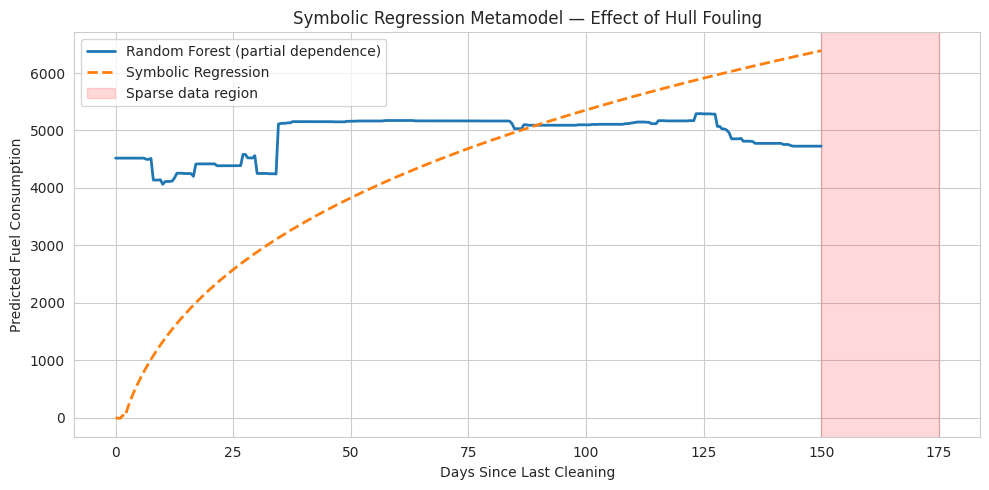

In [126]:
y_symbolic = sr.predict(dsc_range.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dsc_range, y_meta, label="Random Forest (partial dependence)", linewidth=2)
ax.plot(dsc_range, y_symbolic, label="Symbolic Regression", linestyle="--", linewidth=2)

# Shade the sparse region where data is unreliable
ax.axvspan(DSC_MAX, 175, alpha=0.15, color='red', label="Sparse data region")

ax.set_xlabel("Days Since Last Cleaning")
ax.set_ylabel("Predicted Fuel Consumption")
ax.set_title("Symbolic Regression Metamodel — Effect of Hull Fouling")
ax.legend()
plt.tight_layout()
plt.show()

### 3.4.2. Smooth curve

In [212]:
def visualize_coverage(X_train, variable_ranges: dict):
    """
    Plots histograms of training data coverage for specified variables,
    with the scenario range highlighted.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training data.
    variable_ranges : dict
        {feature_name: [min, max]} — the scenario range to highlight.
        Example: {"Avg Draft (Calculated)": [10.0, 14.0],
                  "Days Since Last Cleaning": [0, 150]}
    """
    n_vars = len(variable_ranges)
    ncols = 2
    nrows = math.ceil(n_vars / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    axes = np.array(axes).flatten()  # Always iterable, even for 1 row

    for ax, (var_name, var_range) in zip(axes, variable_ranges.items()):
        range_min, range_max = var_range

        data = X_train[var_name].dropna()

        # Count how much of the data falls within the range
        in_range = data[(data >= range_min) & (data <= range_max)]
        coverage_pct = 100 * len(in_range) / len(data)

        ax.hist(data, bins=50, color='steelblue', alpha=0.6, label="Training data")
        ax.axvspan(range_min, range_max, color='tomato', alpha=0.25,
                   label=f"Scenario range [{range_min}, {range_max}]")
        ax.axvline(range_min, color='tomato', linewidth=1.5, linestyle='--')
        ax.axvline(range_max, color='tomato', linewidth=1.5, linestyle='--')

        ax.set_title(f"{var_name}\n{coverage_pct:.1f}% of training data within range")
        ax.set_xlabel(var_name)
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

    # Hide any unused subplots
    for ax in axes[n_vars:]:
        ax.set_visible(False)

    plt.suptitle("Training Data Coverage for Scenario Variables", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

def fit_and_plot_fouling_curves(
    y_meta,
    dsc_range,
    smooth_window=20,
    title="Curve Fitting — Effect of Hull Fouling on Power",
    ylabel="Predicted Power (kW)",
    raw_label="RF partial dependence (raw)",
):
    """
    Smooths y_meta, fits power law and logarithmic curves to the DSC range,
    plots the result and prints the fitted formulas with evaluation scores.

    Parameters
    ----------
    y_meta       : array-like  — raw RF partial dependence predictions
    dsc_range    : array-like  — DSC values corresponding to y_meta
    smooth_window: int         — rolling average window size (default 20)
    title        : str         — plot title
    ylabel       : str         — y-axis label
    raw_label    : str         — legend label for the raw curve

    Returns
    -------
    results : dict with keys 'popt_pow', 'popt_log', 'y_smooth', 'y_pow', 'y_log'
    """

    def power_law(x, a, b, c):
        return a * np.power(x + 1, b) + c

    def logarithmic(x, a, b, c):
        return a * np.log(x + 1) + b * x + c

    # 1. Smooth
    y_smooth = pd.Series(y_meta).rolling(window=smooth_window, center=True, min_periods=1).mean().values

    # 2. Fit
    popt_pow, _ = curve_fit(power_law,  dsc_range, y_smooth, p0=[100, 0.5, 4000], maxfev=10000)
    popt_log, _ = curve_fit(logarithmic, dsc_range, y_smooth, p0=[100, 1,   4000], maxfev=10000)

    # 3. Generate fitted curves
    y_pow = power_law(dsc_range,   *popt_pow)
    y_log = logarithmic(dsc_range, *popt_log)

    # 4. Evaluate
    rmse_pow = root_mean_squared_error(y_smooth, y_pow)
    rmse_log = root_mean_squared_error(y_smooth, y_log)
    mape_pow = mean_absolute_percentage_error(y_smooth, y_pow)
    mape_log = mean_absolute_percentage_error(y_smooth, y_log)

    # 5. Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(dsc_range, y_meta,   color='steelblue', linewidth=1.5, alpha=0.4, label=raw_label)
    ax.plot(dsc_range, y_smooth, color='steelblue', linewidth=2.0, linestyle='--',
            label=f"{raw_label.split('(')[0].strip()} (smoothed, window={smooth_window})")
    ax.plot(dsc_range, y_pow,    color='tomato',    linewidth=2.0,
            label=f"Power law fit  (RMSE={rmse_pow:.1f}, MAPE={mape_pow*100:.2f}%)\n"
                  f"  f(DSC) = {popt_pow[0]:.2f}·(DSC+1)^{popt_pow[1]:.3f} + {popt_pow[2]:.2f}")
    ax.plot(dsc_range, y_log,    color='seagreen',  linewidth=2.0,
            label=f"Logarithmic fit (RMSE={rmse_log:.1f}, MAPE={mape_log*100:.2f}%)\n"
                  f"  f(DSC) = {popt_log[0]:.2f}·log(DSC+1) + {popt_log[1]:.4f}·DSC + {popt_log[2]:.2f}")

    ax.set_xlabel("Days Since Last Cleaning")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8.5, loc='lower right')
    plt.tight_layout()
    plt.show()

    # 6. Print formulas
    print("=" * 60)
    print("FITTED FORMULAS")
    print("=" * 60)
    print(f"Power law:    f(DSC) = {popt_pow[0]:.2f} * (DSC+1)^{popt_pow[1]:.3f} + {popt_pow[2]:.2f}")
    print(f"              RMSE={rmse_pow:.2f}  |  MAPE={mape_pow*100:.2f}%")
    print()
    print(f"Logarithmic:  f(DSC) = {popt_log[0]:.2f} * log(DSC+1) + {popt_log[1]:.4f} * DSC + {popt_log[2]:.2f}")
    print(f"              RMSE={rmse_log:.2f}  |  MAPE={mape_log*100:.2f}%")

    return {
        "popt_pow": popt_pow, "popt_log": popt_log,
        "y_smooth": y_smooth, "y_pow": y_pow, "y_log": y_log,
        "rmse_pow": rmse_pow, "rmse_log": rmse_log,
        "mape_pow": mape_pow, "mape_log": mape_log,
    }

In [199]:
DSC_MIN = 0
DSC_MAX = 130

#### 3.4.2.1. Fouling curve for median case

In [200]:
X_meta, dsc_range, y_meta = make_synthetic_dataframe(
    pipeline=rf_pipeline,
    X_train=X_train,
    all_predictive_variables=all_predictive_variables,
    dsc_min=DSC_MIN,
    dsc_max=DSC_MAX,
    n_points=151,
)

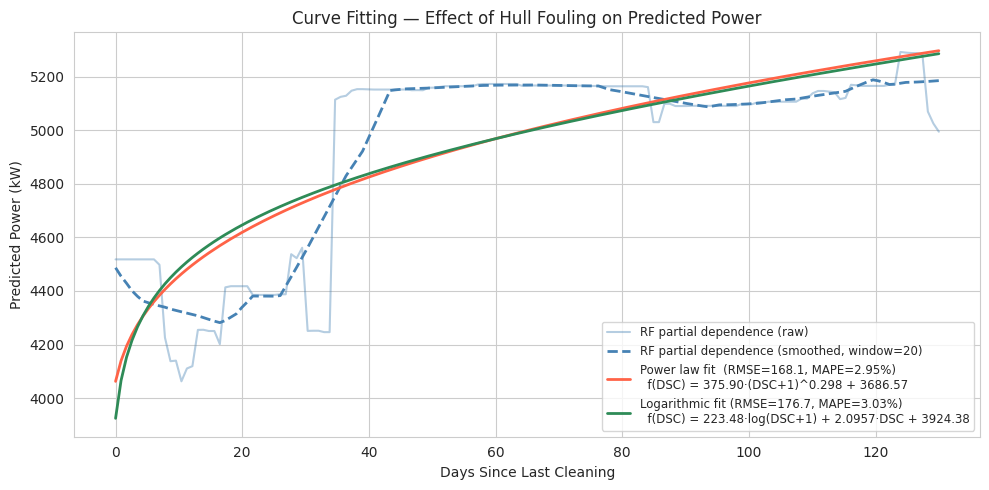

FITTED FORMULAS
Power law:    f(DSC) = 375.90 * (DSC+1)^0.298 + 3686.57
              RMSE=168.11  |  MAPE=2.95%

Logarithmic:  f(DSC) = 223.48 * log(DSC+1) + 2.0957 * DSC + 3924.38
              RMSE=176.69  |  MAPE=3.03%


In [201]:
results = fit_and_plot_fouling_curves(
    y_meta=y_meta,
    dsc_range=dsc_range,
    smooth_window=20,
    title="Curve Fitting — Effect of Hull Fouling on Predicted Power",
    ylabel="Predicted Power (kW)",
    raw_label="RF partial dependence (raw)"
)


#### 3.4.2.2. Fouling curve for different design drafts

<Axes: xlabel='Avg Draft (Calculated)', ylabel='Count'>

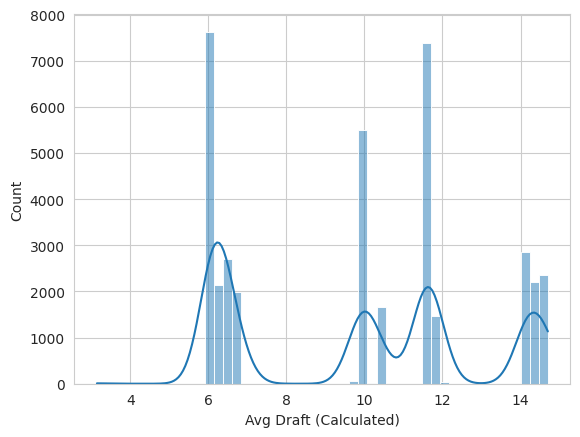

In [202]:
# distribution of drafts in the training data
sns.histplot(X_train["Avg Draft (Calculated)"], bins=50, kde=True)

In [210]:
# print the 50 most common values
print(X_train["Avg Draft (Calculated)"].value_counts().head(50))

Avg Draft (Calculated)
11.615    6275
6.100     5733
9.945     5486
14.200    2779
6.420     2467
14.700    2356
6.280     2145
14.250    2002
6.750     1977
6.145     1888
10.430    1667
11.840    1460
11.470    1054
6.400      232
14.285     211
14.215      67
9.810       62
11.505      53
12.000      44
3.145       33
10.190      23
9.950       20
6.115        5
10.360       4
6.500        3
5.995        1
Name: count, dtype: int64


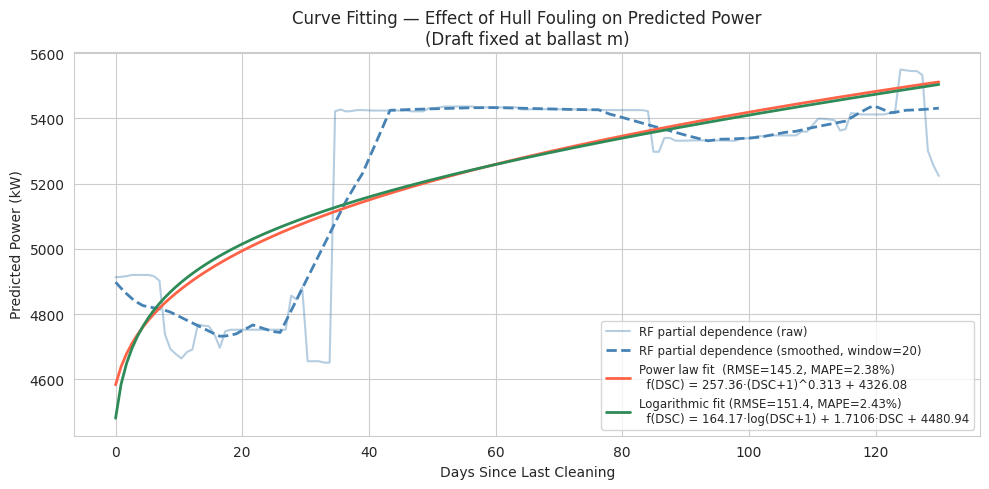

FITTED FORMULAS
Power law:    f(DSC) = 257.36 * (DSC+1)^0.313 + 4326.08
              RMSE=145.18  |  MAPE=2.38%

Logarithmic:  f(DSC) = 164.17 * log(DSC+1) + 1.7106 * DSC + 4480.94
              RMSE=151.37  |  MAPE=2.43%


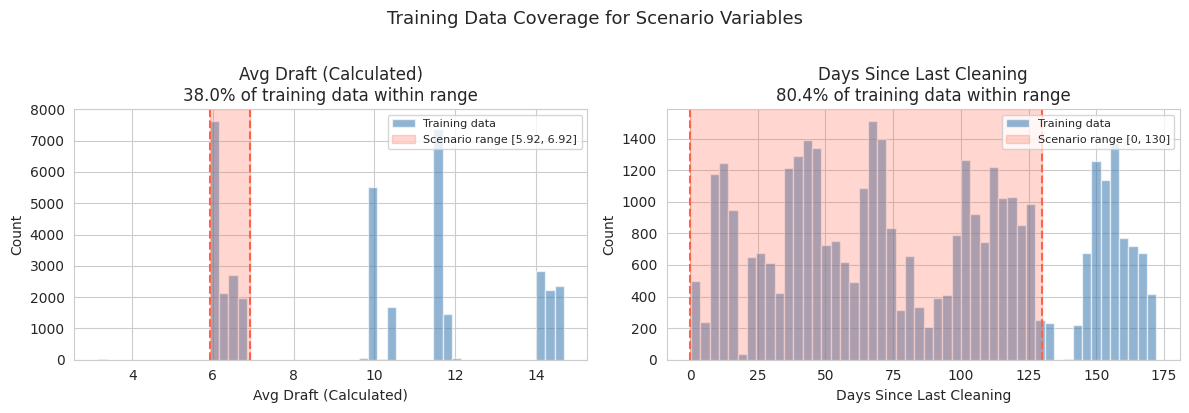

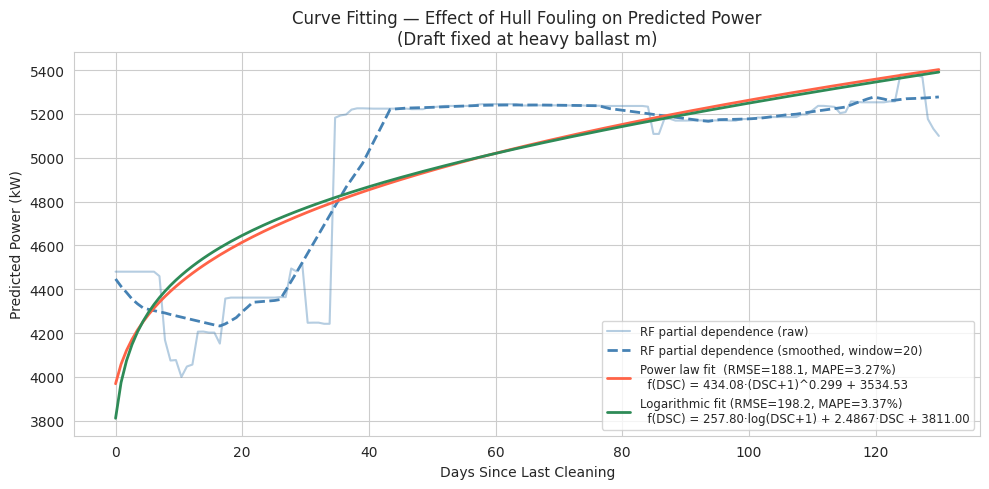

FITTED FORMULAS
Power law:    f(DSC) = 434.08 * (DSC+1)^0.299 + 3534.53
              RMSE=188.14  |  MAPE=3.27%

Logarithmic:  f(DSC) = 257.80 * log(DSC+1) + 2.4867 * DSC + 3811.00
              RMSE=198.18  |  MAPE=3.37%


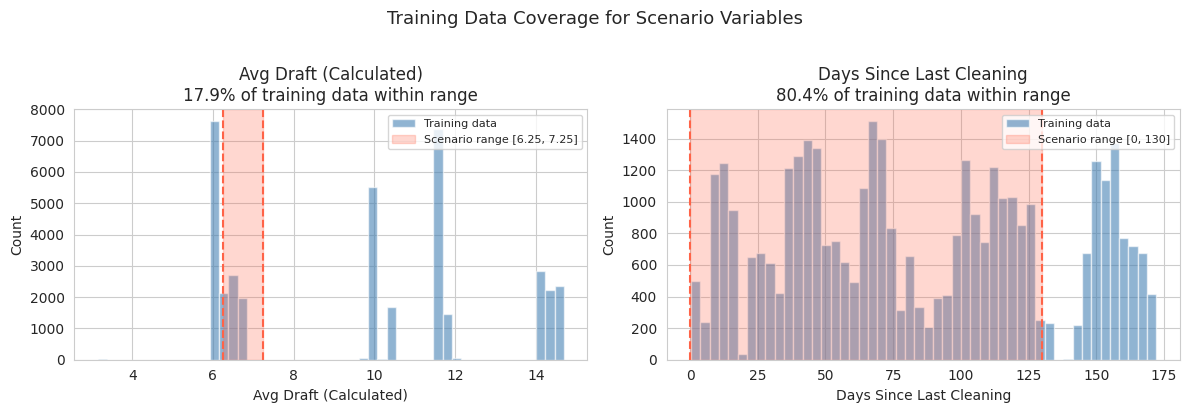

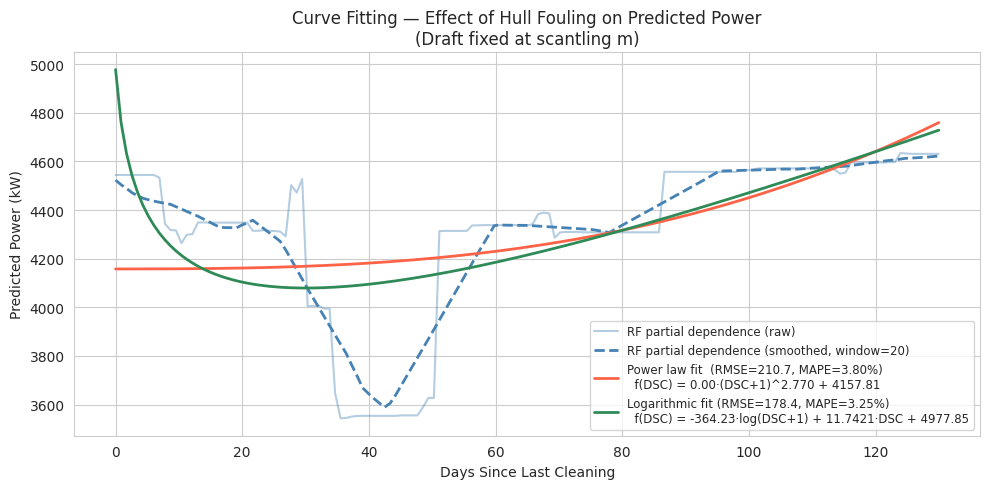

FITTED FORMULAS
Power law:    f(DSC) = 0.00 * (DSC+1)^2.770 + 4157.81
              RMSE=210.71  |  MAPE=3.80%

Logarithmic:  f(DSC) = -364.23 * log(DSC+1) + 11.7421 * DSC + 4977.85
              RMSE=178.35  |  MAPE=3.25%


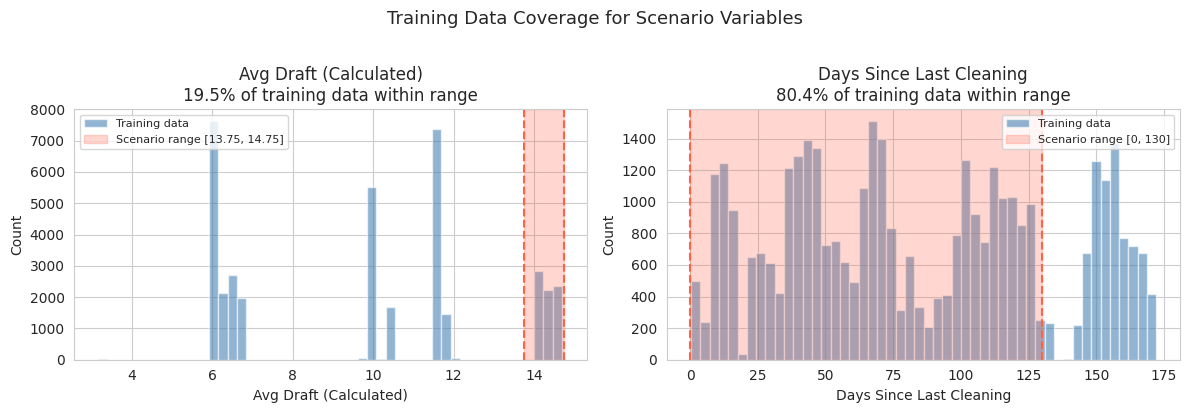

In [218]:
drafts_to_test = [6.42, 6.75, 14.25]  # ballast, heavy ballast, scantling

for draft, value in zip(drafts_to_test, ["ballast", "heavy ballast", "scantling"]):
    X_meta, dsc_range, y_meta = make_synthetic_dataframe(
        pipeline=rf_pipeline,
        X_train=X_train,
        all_predictive_variables=all_predictive_variables,
        dsc_min=DSC_MIN,
        dsc_max=DSC_MAX,
        n_points=151,
        variable_values={"Avg Draft (Calculated)": draft},
    )

    results = fit_and_plot_fouling_curves(
        y_meta=y_meta,
        dsc_range=dsc_range,
        smooth_window=20,
        title=f"Curve Fitting — Effect of Hull Fouling on Predicted Power\n(Draft fixed at {value} m)",
        ylabel="Predicted Power (kW)",
        raw_label="RF partial dependence (raw)"
    )

    visualize_coverage(
        X_train=X_train,
        variable_ranges = {
            'Avg Draft (Calculated)': [draft-0.5, draft+0.5],
            'Days Since Last Cleaning': [DSC_MIN, DSC_MAX]
            },
        
        )

#### 3.4.2.3. Fouling effect at different speeds

<Axes: xlabel='Vessel Hull Through Water Longitudinal Speed (knots)', ylabel='Count'>

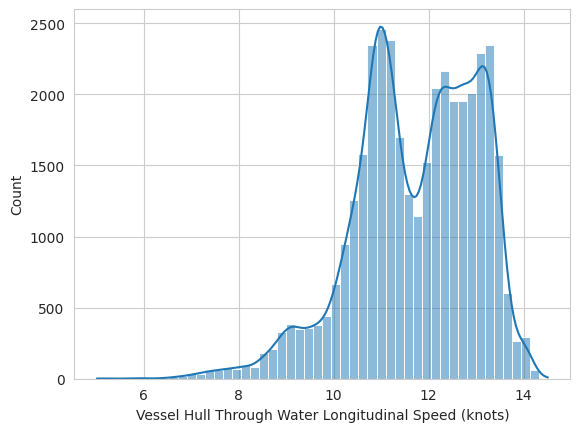

In [206]:
# plot distribution of speed through water in the training data
sns.histplot(X_train["Vessel Hull Through Water Longitudinal Speed (knots)"], bins=50, kde=True)

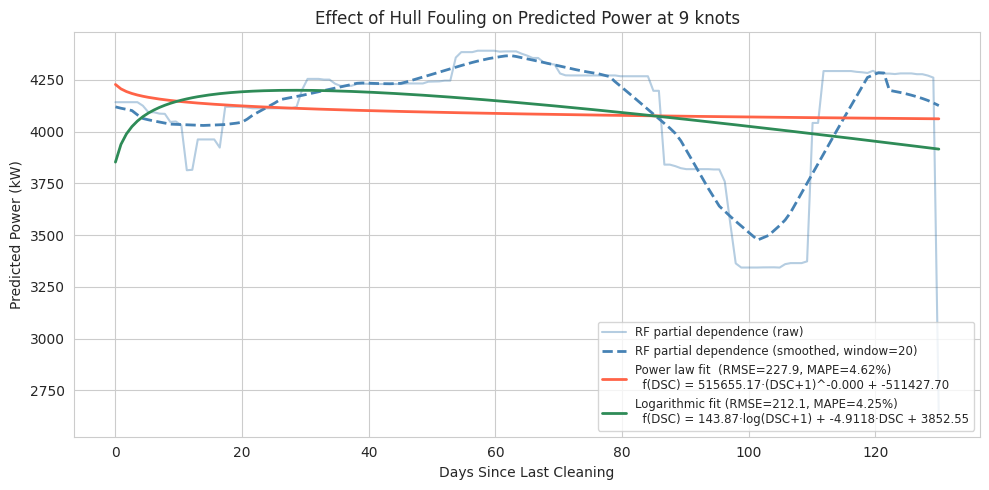

FITTED FORMULAS
Power law:    f(DSC) = 515655.17 * (DSC+1)^-0.000 + -511427.70
              RMSE=227.94  |  MAPE=4.62%

Logarithmic:  f(DSC) = 143.87 * log(DSC+1) + -4.9118 * DSC + 3852.55
              RMSE=212.09  |  MAPE=4.25%


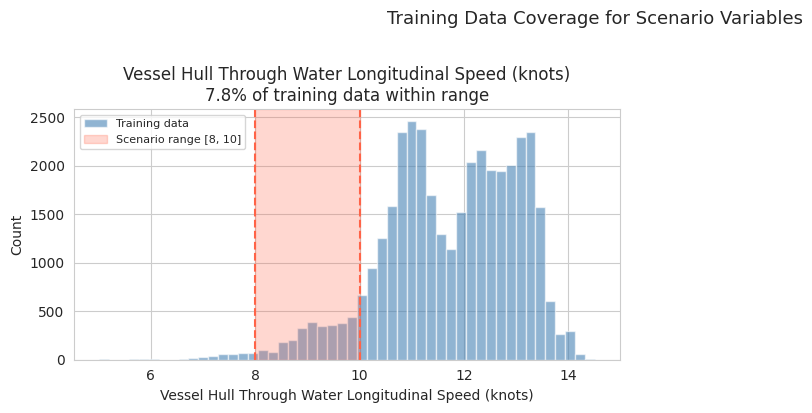

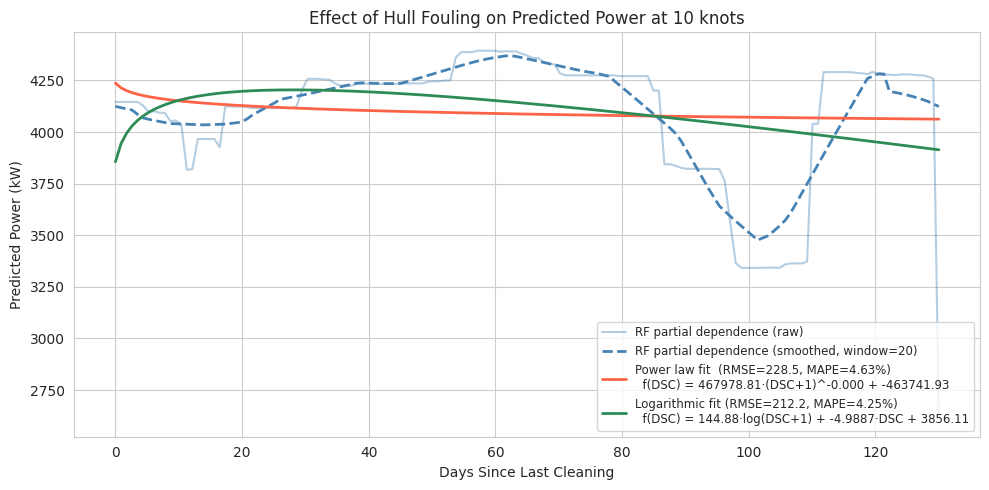

FITTED FORMULAS
Power law:    f(DSC) = 467978.81 * (DSC+1)^-0.000 + -463741.93
              RMSE=228.52  |  MAPE=4.63%

Logarithmic:  f(DSC) = 144.88 * log(DSC+1) + -4.9887 * DSC + 3856.11
              RMSE=212.20  |  MAPE=4.25%


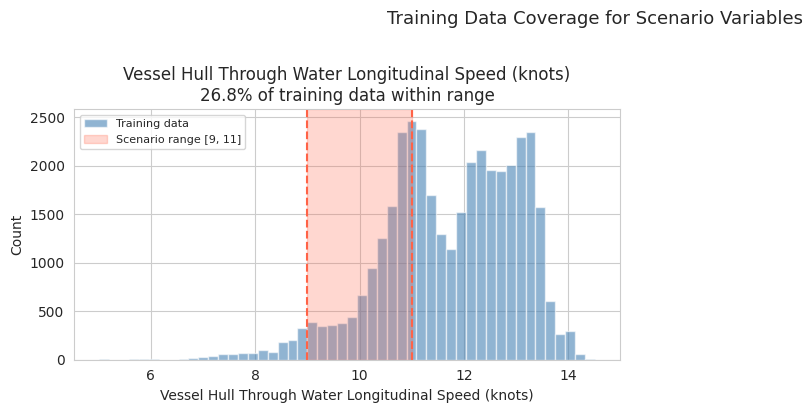

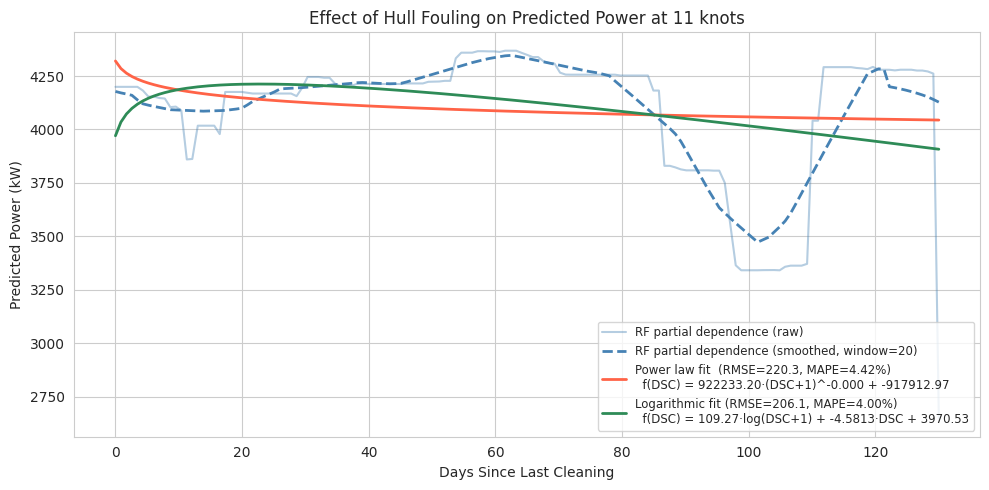

FITTED FORMULAS
Power law:    f(DSC) = 922233.20 * (DSC+1)^-0.000 + -917912.97
              RMSE=220.32  |  MAPE=4.42%

Logarithmic:  f(DSC) = 109.27 * log(DSC+1) + -4.5813 * DSC + 3970.53
              RMSE=206.09  |  MAPE=4.00%


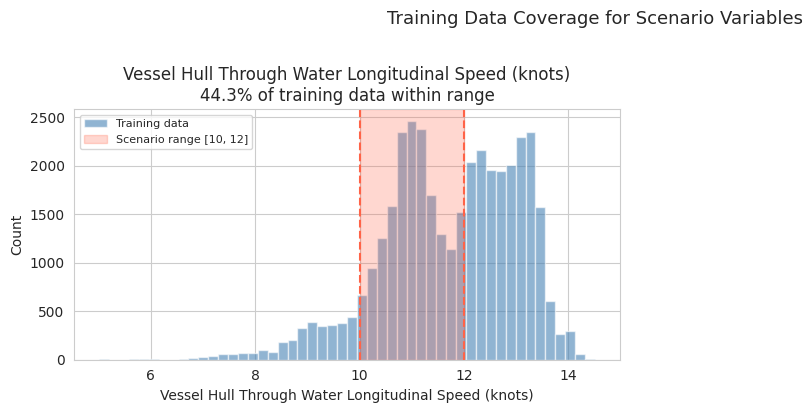

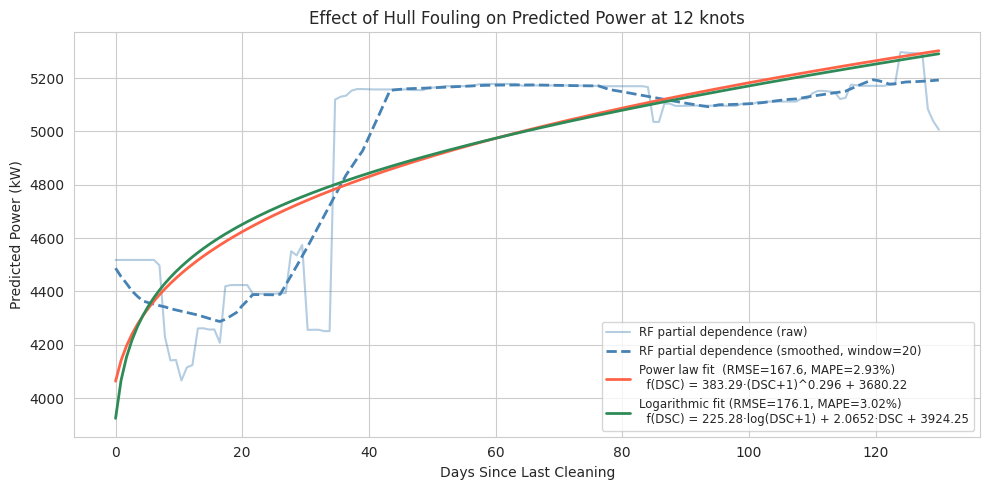

FITTED FORMULAS
Power law:    f(DSC) = 383.29 * (DSC+1)^0.296 + 3680.22
              RMSE=167.57  |  MAPE=2.93%

Logarithmic:  f(DSC) = 225.28 * log(DSC+1) + 2.0652 * DSC + 3924.25
              RMSE=176.12  |  MAPE=3.02%


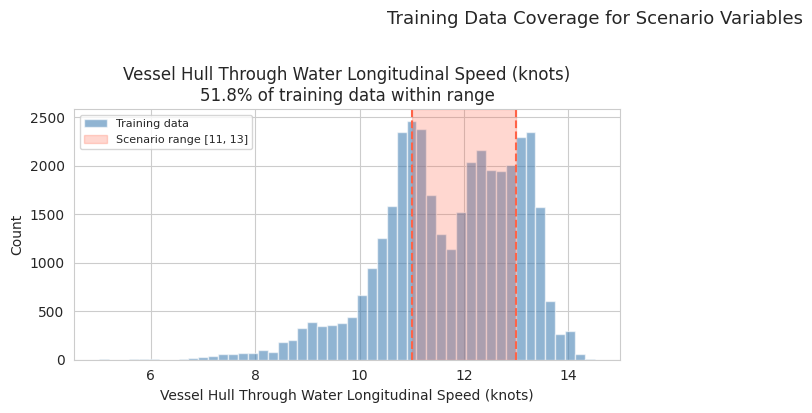

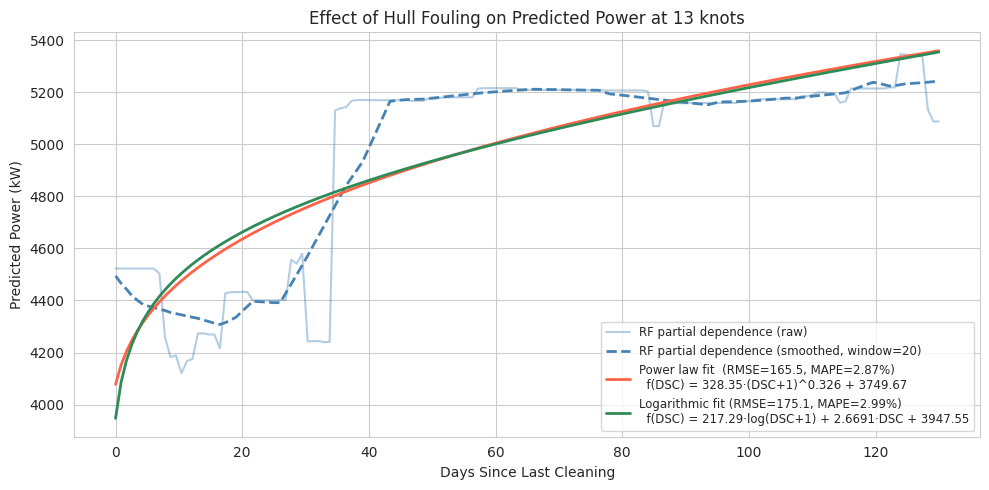

FITTED FORMULAS
Power law:    f(DSC) = 328.35 * (DSC+1)^0.326 + 3749.67
              RMSE=165.47  |  MAPE=2.87%

Logarithmic:  f(DSC) = 217.29 * log(DSC+1) + 2.6691 * DSC + 3947.55
              RMSE=175.14  |  MAPE=2.99%


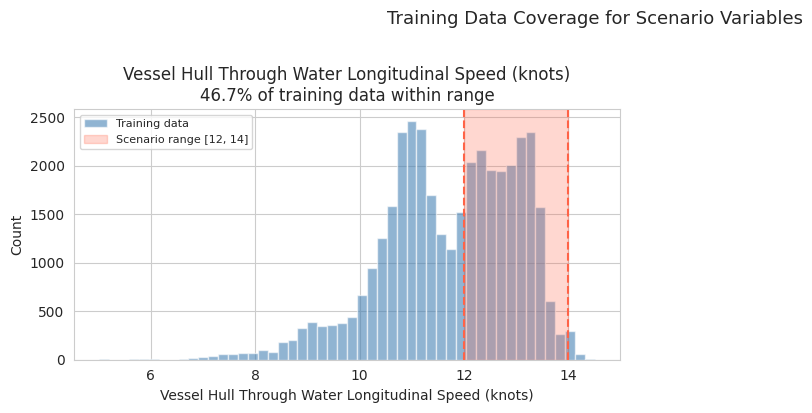

In [220]:
speeds_to_test = [9,10,11,12,13]

for speed in speeds_to_test:
    X_meta_speed, dsc_range, y_meta_speed = make_synthetic_dataframe(
        pipeline=rf_pipeline,
        X_train=X_train,
        all_predictive_variables=all_predictive_variables,
        dsc_min=DSC_MIN,
        dsc_max=DSC_MAX,
        n_points=151,
        variable_values={"Vessel Hull Through Water Longitudinal Speed (knots)": speed},
    )

    fit_and_plot_fouling_curves(
        y_meta=y_meta_speed,
        dsc_range=dsc_range,
        smooth_window=20,
        title=f"Effect of Hull Fouling on Predicted Power at {speed} knots",
        ylabel="Predicted Power (kW)",
        raw_label="RF partial dependence (raw)"
    )

    visualize_coverage(
        X_train=X_train,
        variable_ranges={'Vessel Hull Through Water Longitudinal Speed (knots)': [speed-1, speed+1]}
    )

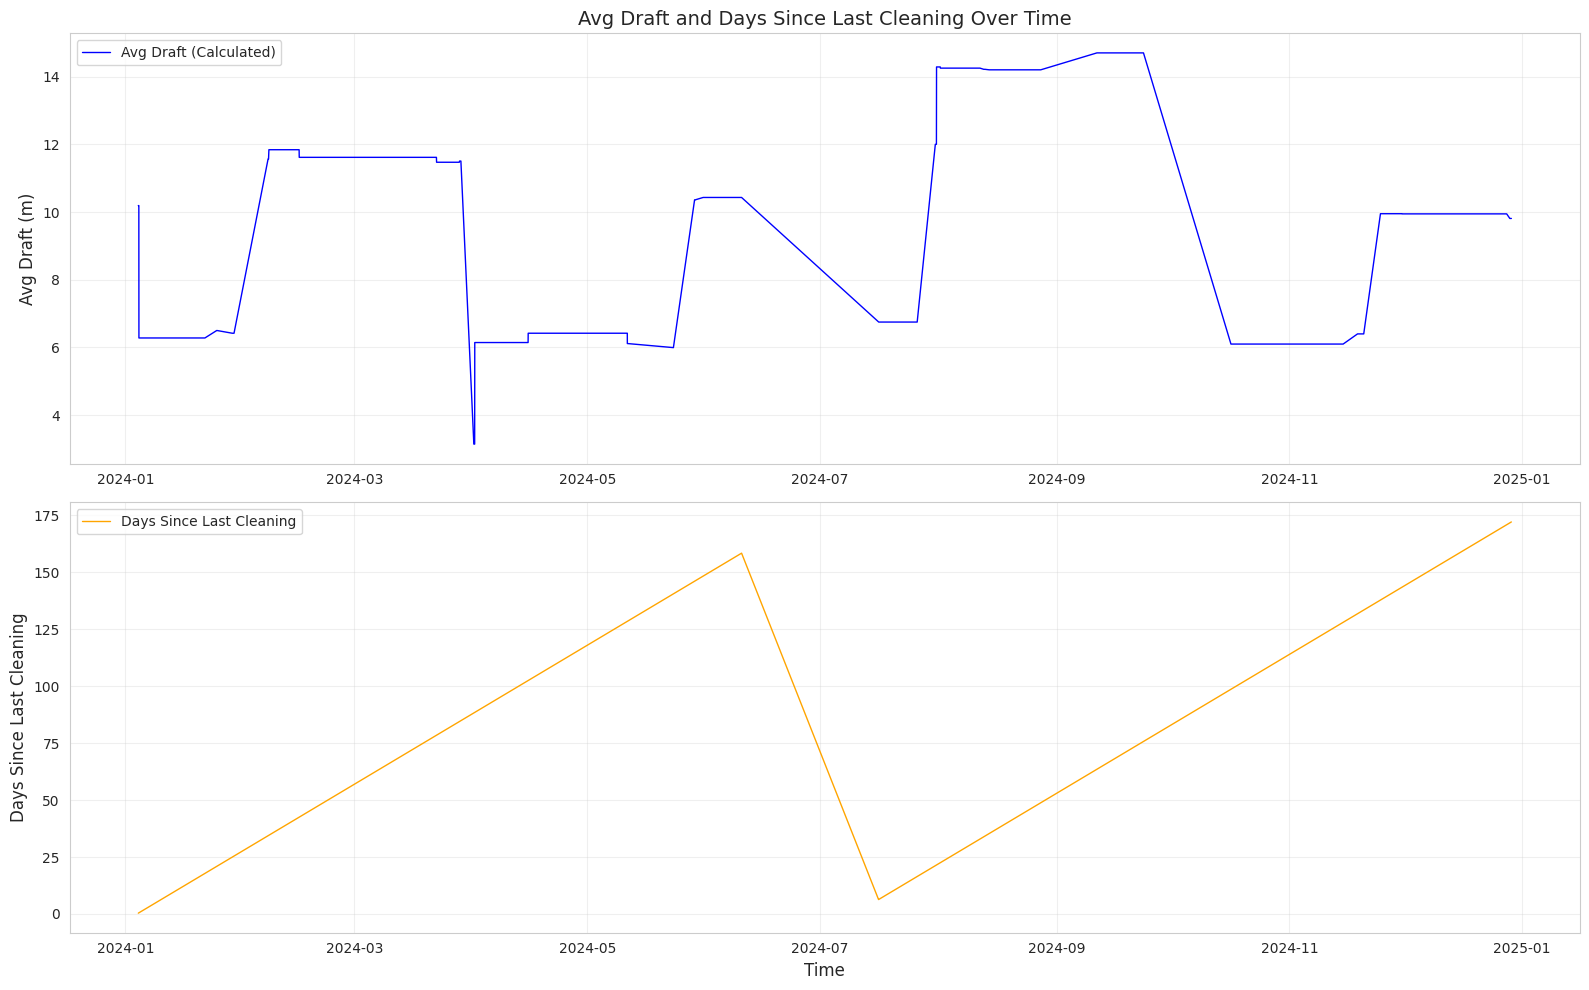

In [208]:
#plot draft and days since cleaning over time ion the same line plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

ax1.plot(model_df["window_start"], model_df["Avg Draft (Calculated)"], label="Avg Draft (Calculated)", color="blue", linewidth=1)
ax1.set_ylabel("Avg Draft (m)", fontsize=12)
ax1.set_title("Avg Draft and Days Since Last Cleaning Over Time", fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(model_df["window_start"], model_df["Days Since Last Cleaning"], label="Days Since Last Cleaning", color="orange", linewidth=1)
ax2.set_xlabel("Time", fontsize=12)
ax2.set_ylabel("Days Since Last Cleaning", fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
